# Shot chart 

Source: `data/raw/teams/unleash-the-clowns/match.html`

In [1]:
from pathlib import Path
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import urllib.request

HTML_PATH = Path("../data/raw/teams/unleash-the-clowns/match.html")
PLAYER_ID = "302" 

In [2]:
with open(HTML_PATH, encoding="utf-8") as f:
    soup = BeautifulSoup(f, "lxml")

shots = []
for g in soup.select(f'g[data-user="{PLAYER_ID}"]'):
    circle = g.find("circle")
    stat = g["data-stat"]
    shots.append({
        "period": int(g["data-period"]) + 1,
        "shot_type": "2PT" if stat.startswith("2") else "3PT",
        "made": stat.endswith("S"),
        "x": int(circle["cx"]),
        "y": int(circle["cy"]),
    })

shots_df = pd.DataFrame(shots)
shots_df

,period,shot_type,made,x,y
0,1,2PT,True,912,288
1,2,2PT,False,910,238
2,3,2PT,True,931,252
3,2,3PT,False,880,477
4,2,3PT,False,833,48
5,2,3PT,False,821,78
6,2,3PT,True,721,214
7,2,3PT,False,812,55


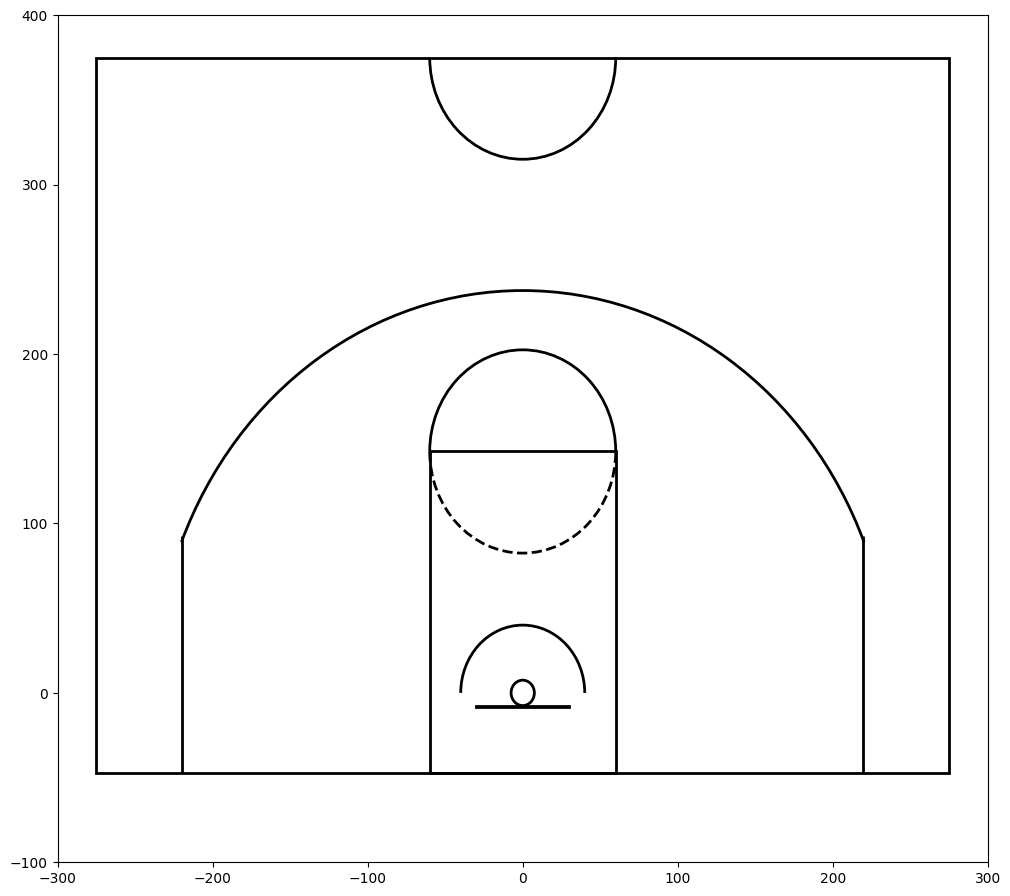

In [3]:
from matplotlib.patches import Circle, Rectangle, Arc

def draw_court(ax=None, color='black', lw=2, outer_lines=False):
    # If an axes object isn't provided to plot onto, just get current one
    if ax is None:
        ax = plt.gca()

    # Create the various parts of an NBA basketball court

    # Create the basketball hoop
    # Diameter of a hoop is 18" so it has a radius of 9", which is a value
    # 7.5 in our coordinate system
    hoop = Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)

    # Create backboard
    backboard = Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color)

    # The paint
    # Create the outer box 0f the paint, width=16ft, height=19ft
    outer_box = Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color,
                          fill=False)
    # Create the inner box of the paint, widt=12ft, height=19ft
    inner_box = Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color,
                          fill=False)

    # Create free throw top arc
    top_free_throw = Arc((0, 142.5), 120, 120, theta1=0, theta2=180,
                         linewidth=lw, color=color, fill=False)
    # Create free throw bottom arc
    bottom_free_throw = Arc((0, 142.5), 120, 120, theta1=180, theta2=0,
                            linewidth=lw, color=color, linestyle='dashed')
    # Restricted Zone, it is an arc with 4ft radius from center of the hoop
    restricted = Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw,
                     color=color)

    # Three point line
    # Create the side 3pt lines, they are 14ft long before they begin to arc
    corner_three_a = Rectangle((-220, -47.5), 0, 140, linewidth=lw,
                               color=color)
    corner_three_b = Rectangle((219.5, -47.5), 0, 140, linewidth=lw, color=color)
    # 3pt arc - center of arc will be the hoop, arc is 23'9" away from hoop
    # I just played around with the theta values until they lined up with the 
    # threes
    three_arc = Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw,
                    color=color)

    # Center Court
    center_outer_arc = Arc((0, 375), 120, 120, theta1=180, theta2=0,
                           linewidth=lw, color=color)
    center_inner_arc = Arc((0, 422.5), 40, 40, theta1=180, theta2=0,
                           linewidth=lw, color=color)

    # List of the court elements to be plotted onto the axes
    court_elements = [hoop, backboard, inner_box, top_free_throw,
                      bottom_free_throw, restricted, corner_three_a,
                      corner_three_b, three_arc, center_outer_arc]

    if outer_lines:
        # Draw the half court line, baseline and side out bound lines
        outer_lines = Rectangle((-275, -47.5), 550, 422.5, linewidth=lw,
                                color=color, fill=False)
        court_elements.append(outer_lines)

    # Add the court elements onto the axes
    for element in court_elements:
        ax.add_patch(element)

    return ax



plt.figure(figsize=(12,11))
draw_court(outer_lines=True)
plt.xlim(-300,300)
plt.ylim(-100,400)
plt.show()



In [4]:
HOOP_X, HOOP_Y = 944, 250
SCALE = 1.16

shots_df["court_x"] = (HOOP_Y - shots_df["y"]) * SCALE 
shots_df["court_y"] = (HOOP_X - shots_df["x"]) * SCALE


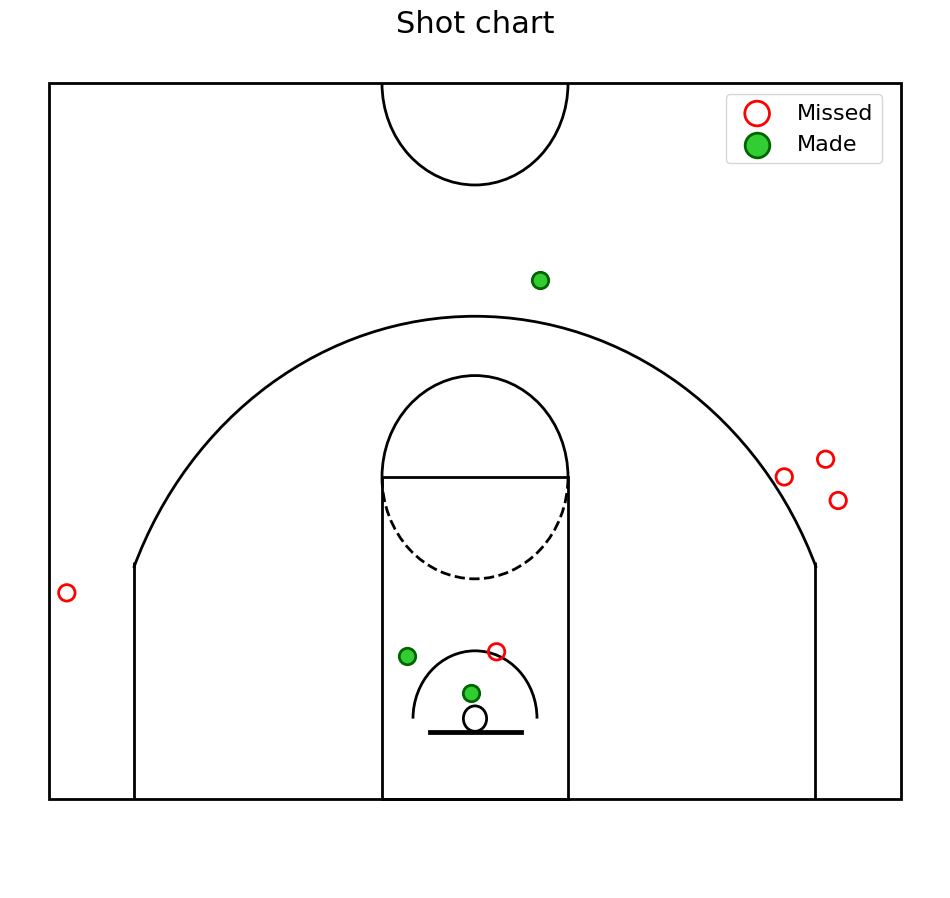

In [5]:
fig, ax = plt.subplots(figsize=(12, 11))
draw_court(ax, outer_lines=True)

made = shots_df[shots_df["made"]]
missed = shots_df[~shots_df["made"]]

ax.scatter(missed["court_x"], missed["court_y"], facecolors="none", edgecolors="red",
           s=140, linewidths=2, label="Missed")
ax.scatter(made["court_x"], made["court_y"], facecolors="limegreen", edgecolors="darkgreen",
           s=140, linewidths=2, label="Made")

ax.set_xlim(-300, 300)
ax.set_ylim(-100, 400)
ax.set_title("Shot chart")
ax.set_title("Shot chart", fontsize=22)
ax.legend(loc="upper right", bbox_to_anchor=(0.95, 0.95), fontsize=16, markerscale=1.5)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
plt.show()


# Time to iterate for the whole away team

In [6]:
away_players = {}
for label in soup.select("label.player-check.away"):
    pid = label.find("input")["id"].replace("player-", "")
    name = label.find_parent("div", class_="player-name").get_text(strip=True)
    away_players[pid] = name

away_players


{'68': 'Ζέρβας, Παναγιώτης',
 '266': 'Glynos, Pavlos',
 '270': 'Χαλκίτης, Ηλίας',
 '297': 'Βαμβακαρης, Φραγκισκος',
 '302': 'Βασσάκης , Νικόλαος',
 '696': 'Sourgias, Panagiotis',
 '943': 'Παπαδατος, Σπυριδων Γρηγοριος'}

In [7]:
def get_shots(soup, player_id):
    shots = []
    for g in soup.select(f'g[data-user="{player_id}"]'):
        circle = g.find("circle")
        stat = g["data-stat"]
        shots.append({
            "period": int(g["data-period"]) + 1,
            "shot_type": "2PT" if stat.startswith("2") else "3PT",
            "made": stat.endswith("S"),
            "x": int(circle["cx"]),
            "y": int(circle["cy"]),
        })
    return pd.DataFrame(shots)


In [8]:
def plot_shot_chart(df, player_name, hoop_x=HOOP_X, hoop_y=HOOP_Y, scale_x=1.16, scale_y=1.16):
    df = df.copy()
    df["court_x"] = (hoop_y - df["y"]) * scale_x
    df["court_y"] = (hoop_x - df["x"]) * scale_y

    fig, ax = plt.subplots(figsize=(12, 11))
    draw_court(ax, outer_lines=True)

    made = df[df["made"]]
    missed = df[~df["made"]]

    ax.scatter(missed["court_x"], missed["court_y"], facecolors="none", edgecolors="red",
               s=140, linewidths=2, label="Missed")
    ax.scatter(made["court_x"], made["court_y"], facecolors="limegreen", edgecolors="darkgreen",
               s=140, linewidths=2, label="Made")

    ax.set_xlim(-300, 300)
    ax.set_ylim(-100, 400)
    ax.set_title(f"Shot chart - {player_name}", fontsize=22, fontweight="bold")
    ax.legend(loc="upper right", bbox_to_anchor=(0.95, 0.95), fontsize=16, markerscale=1.5)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.show()


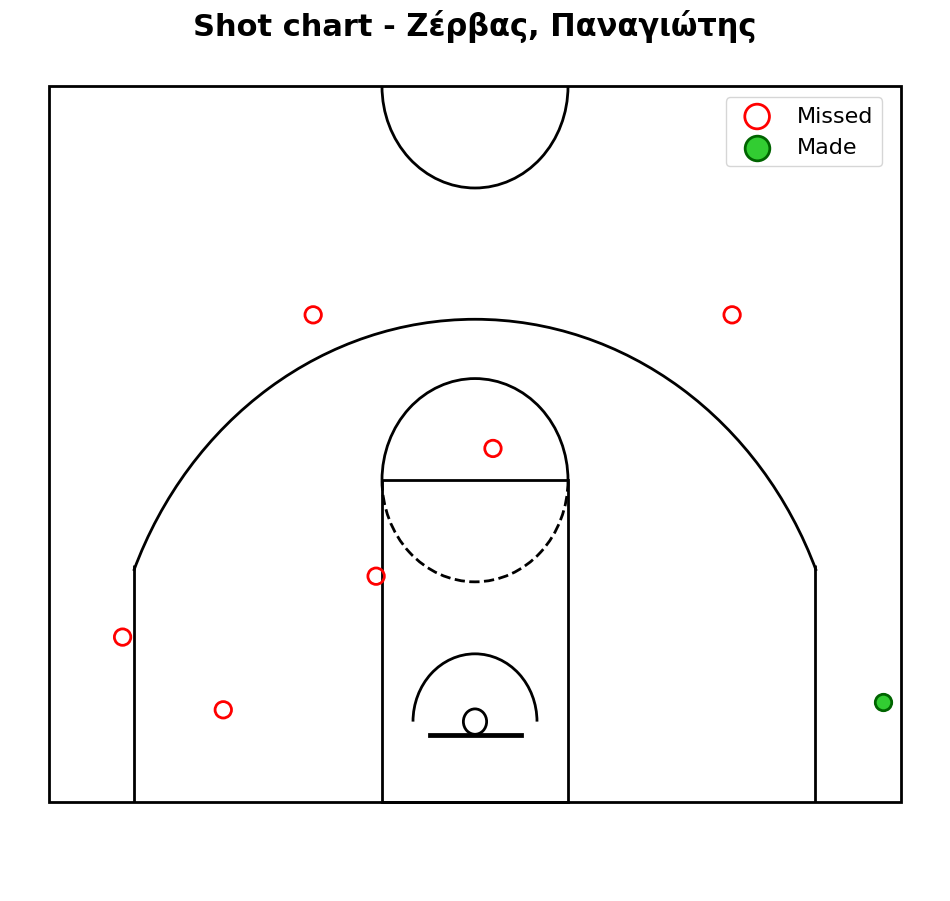

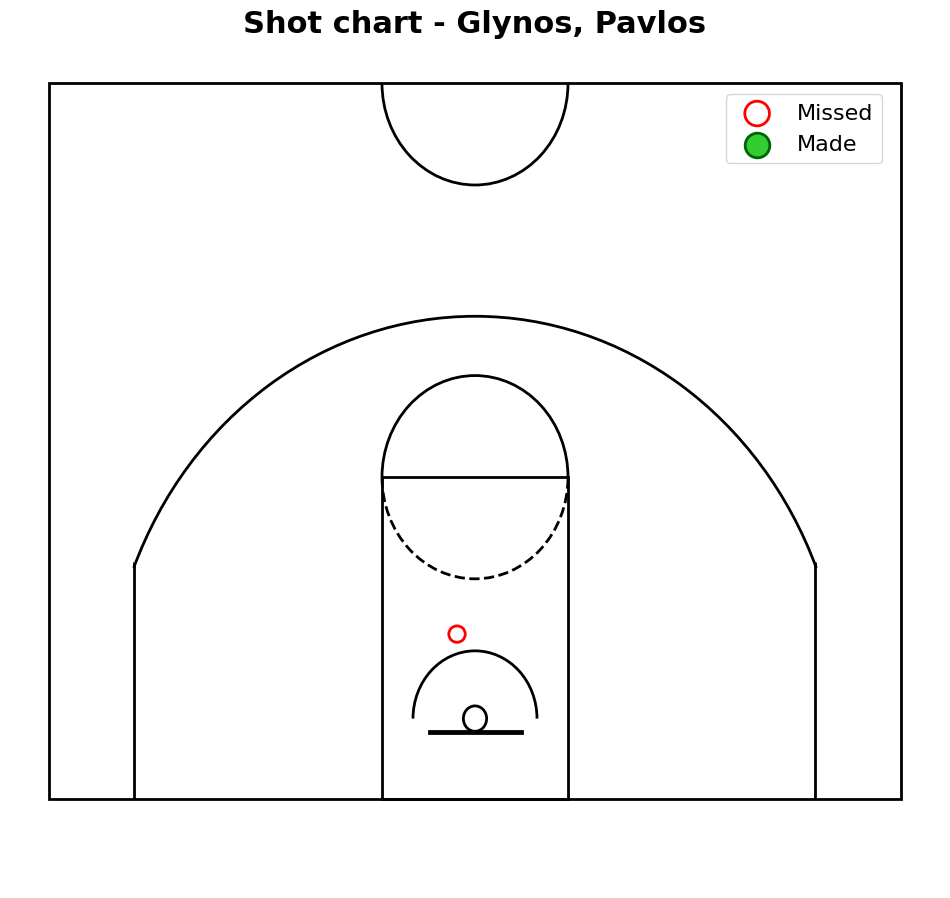

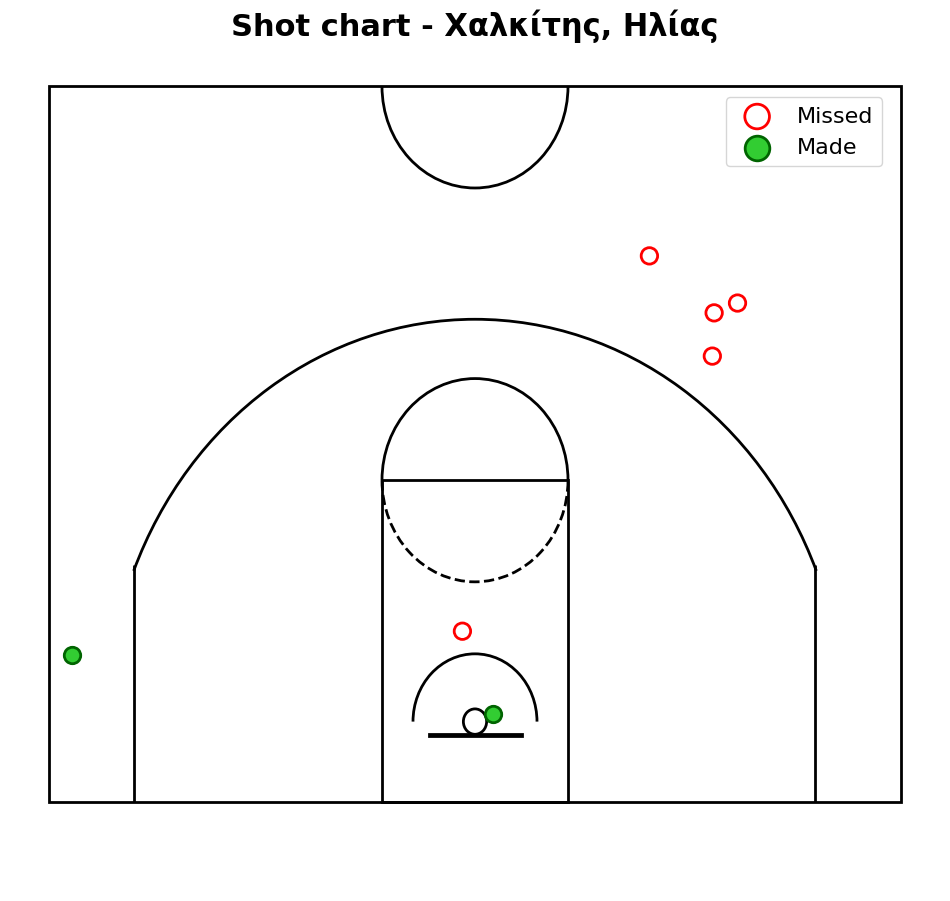

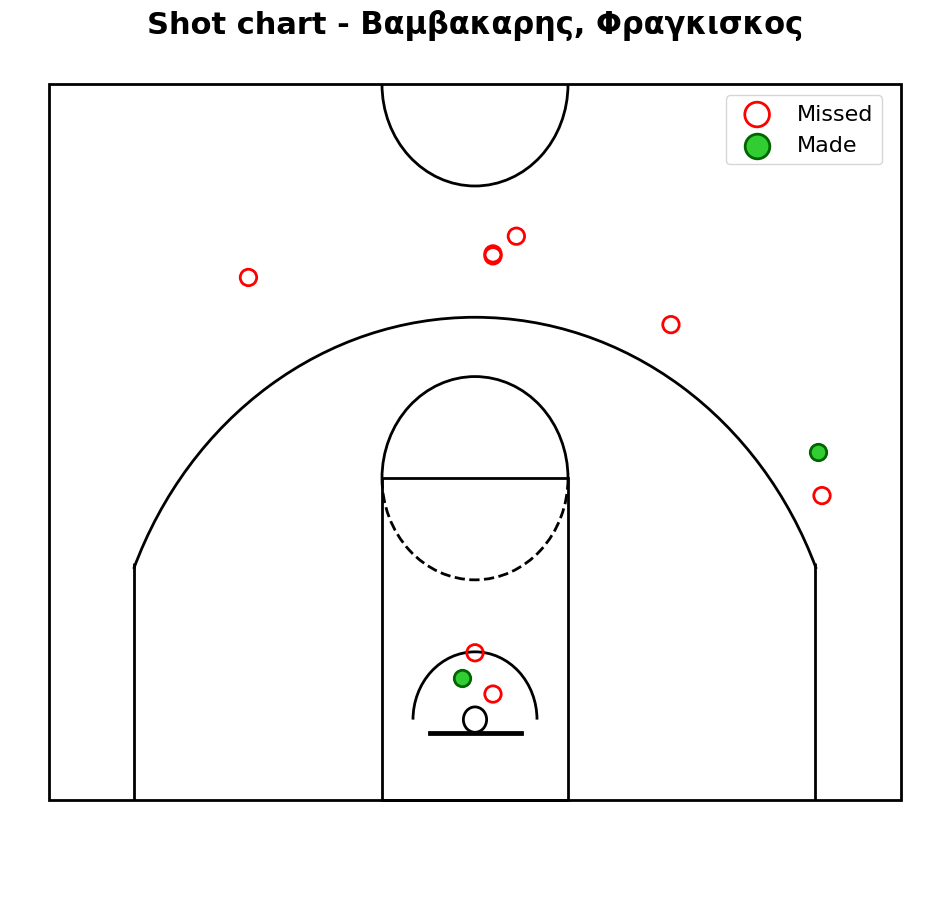

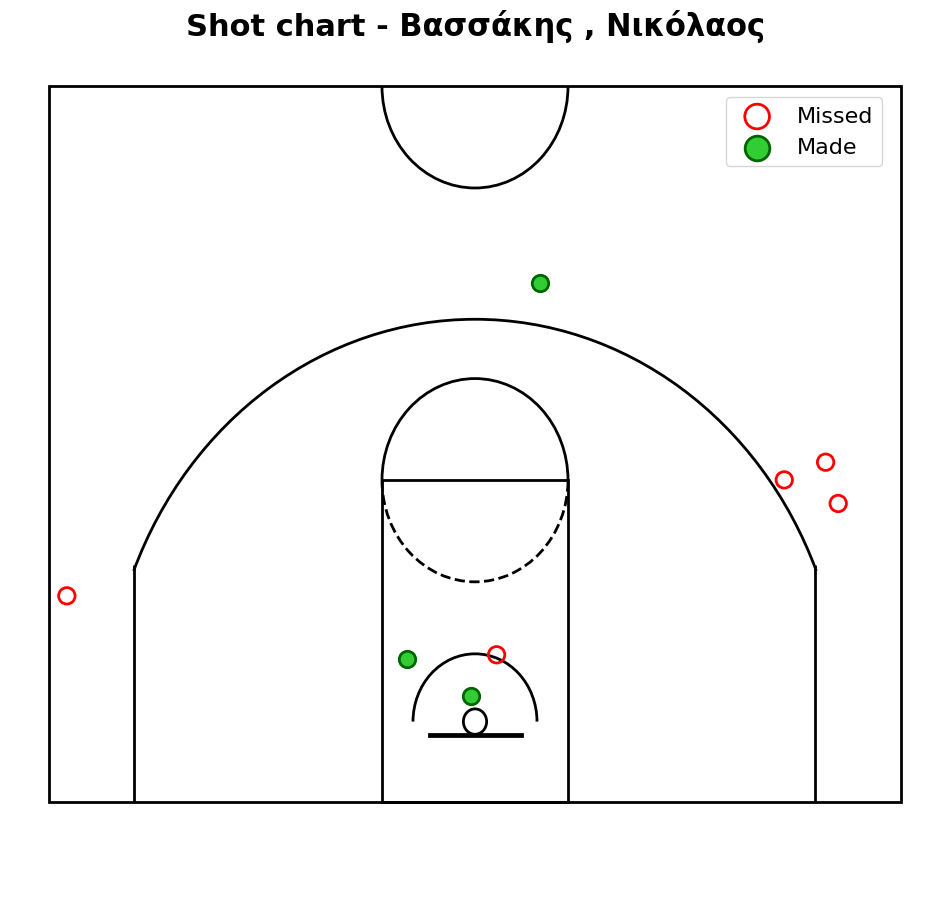

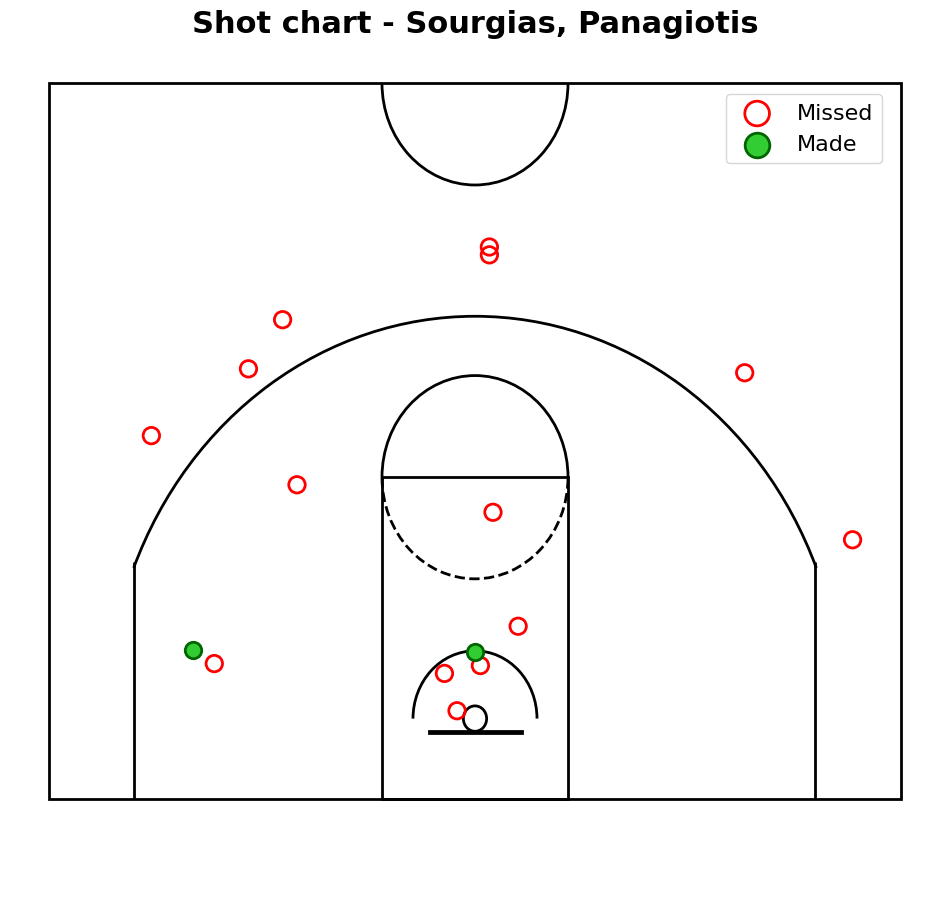

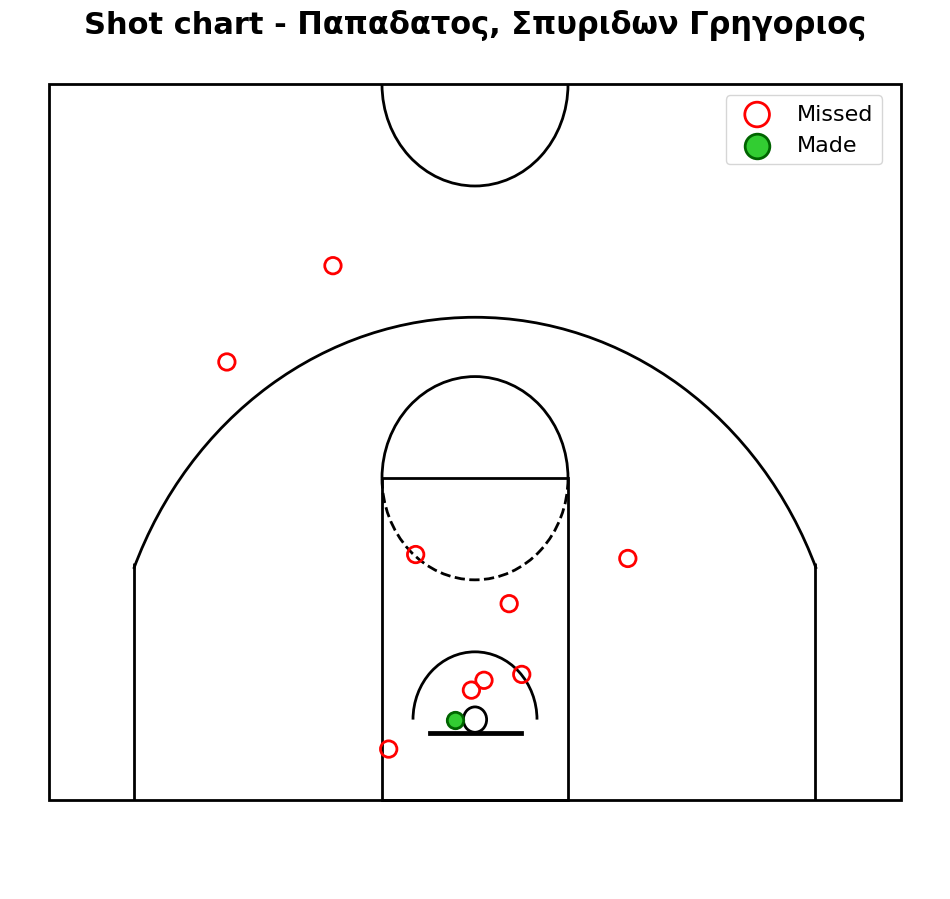

In [9]:
for pid, name in away_players.items():
    df = get_shots(soup, pid)
    if df.empty:
        continue
    plot_shot_chart(df, name)

# Get shot charts from both teams

In [10]:
def get_roster(soup, team):
    players = {}
    for label in soup.select("label.player-check"):
        classes = label.get("class", [])
        is_away = "away" in classes
        if (team == "away") != is_away:
            continue
        pid = label.find("input")["id"].replace("player-", "")
        name = label.find_parent("div", class_="player-name").get_text(strip=True)
        players[pid] = name
    return players

away_players = get_roster(soup, "away")
home_players = get_roster(soup, "home")

print("Away team players:")
for pid, name in away_players.items():
    print(f"{pid}: {name}")                 

print("\nHome team players:")
for pid, name in home_players.items():
    print(f"{pid}: {name}")


Away team players:
68: Ζέρβας, Παναγιώτης
266: Glynos, Pavlos
270: Χαλκίτης, Ηλίας
297: Βαμβακαρης, Φραγκισκος
302: Βασσάκης , Νικόλαος
696: Sourgias, Panagiotis
943: Παπαδατος, Σπυριδων Γρηγοριος

Home team players:
101: Απικος, Νικήτας
105: Αποικος , Αντώνης
122: Φραντζεσκος, Μιχαλης
143: Βαριας, Χρηστος
179: Γιαλελης, Στέλιος
811: Μερτζάνης, Σταυρος
860: Ανδρικόπουλος , Θανος
891: Πετρακακης, Γιωργος
98: Βλαχος, Αλεξανδρος


In [11]:
HOOP_X_AWAY = 944
HOOP_X_HOME = 1000 - HOOP_X_AWAY  # 56
HOOP_Y = 250

def plot_shot_chart(df, player_name, team, scale_x=1.16, scale_y=1.16):
    df = df.copy()
    if team == "away":
        df["court_x"] = (HOOP_Y - df["y"]) * scale_x
        df["court_y"] = (HOOP_X_AWAY - df["x"]) * scale_y
    else:  # home
        df["court_x"] = (df["y"] - HOOP_Y) * scale_x
        df["court_y"] = (df["x"] - HOOP_X_HOME) * scale_y

    fig, ax = plt.subplots(figsize=(12, 11))
    draw_court(ax, outer_lines=True)

    made = df[df["made"]]
    missed = df[~df["made"]]

    ax.scatter(missed["court_x"], missed["court_y"], facecolors="none", edgecolors="red",
               s=140, linewidths=2, label="Missed")
    ax.scatter(made["court_x"], made["court_y"], facecolors="limegreen", edgecolors="darkgreen",
               s=140, linewidths=2, label="Made")

    ax.set_xlim(-300, 300)
    ax.set_ylim(-100, 400)
    ax.set_title(f"Shot chart - Player: {player_name}", fontsize=22, fontweight="bold")
    ax.legend(loc="upper right", bbox_to_anchor=(0.95, 0.95), fontsize=16, markerscale=1.5)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.show()


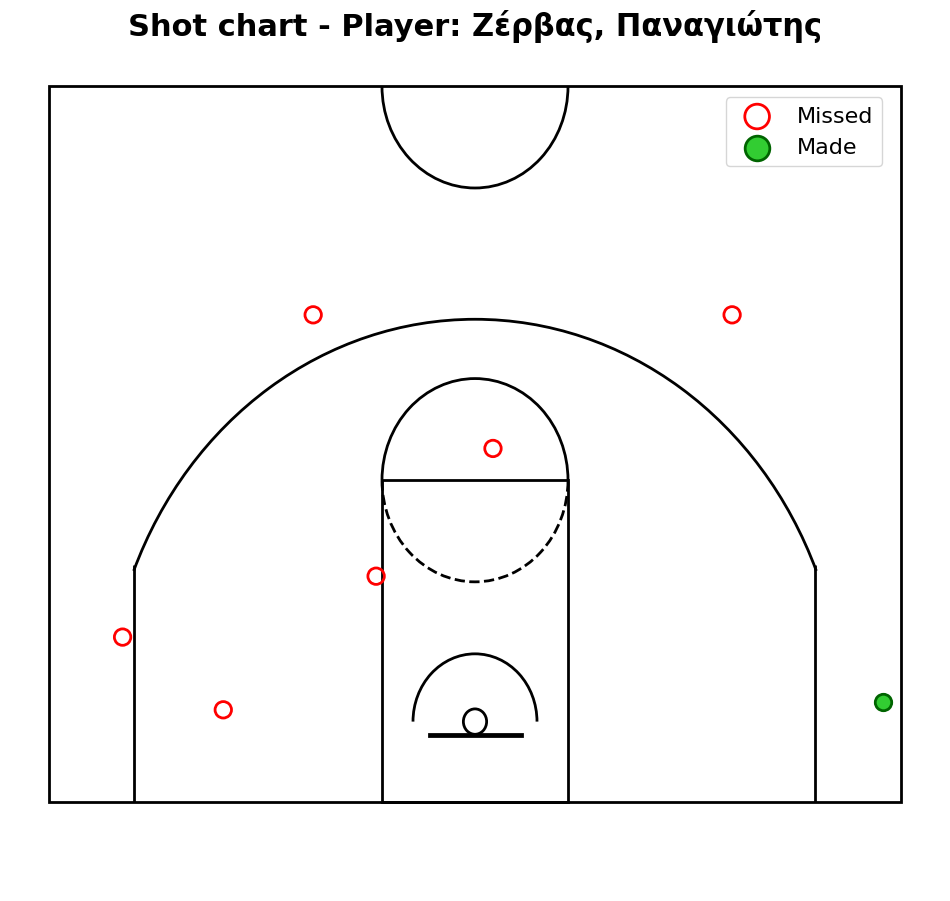

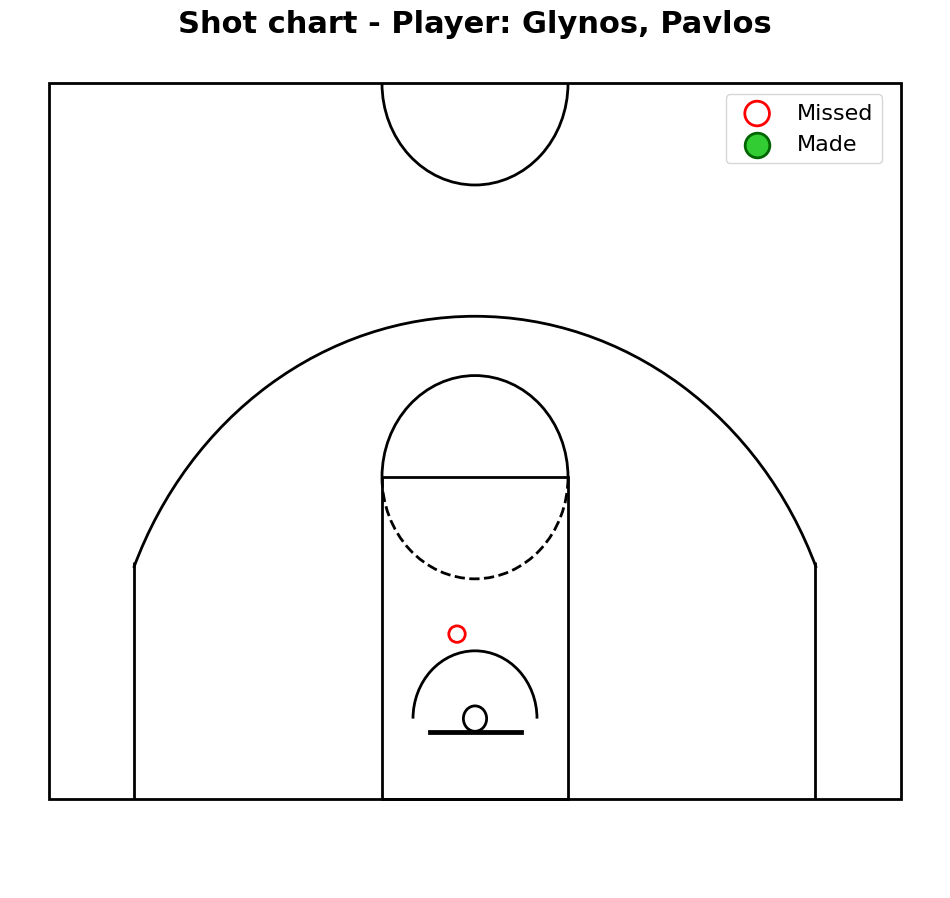

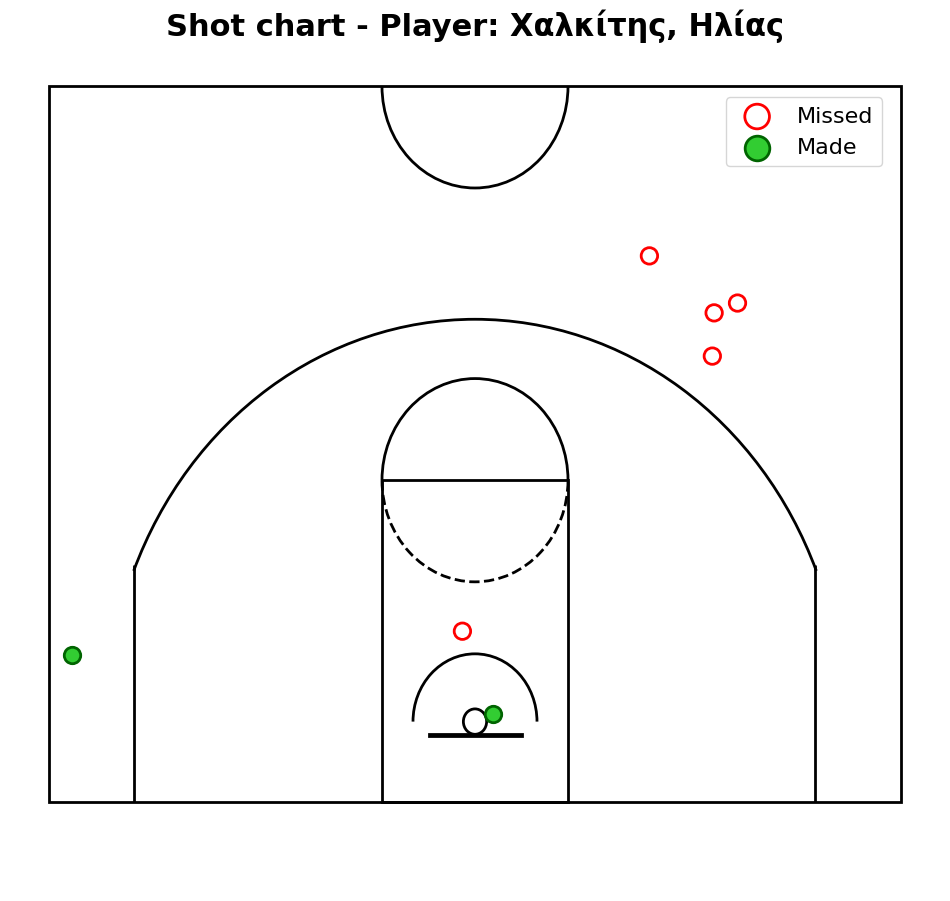

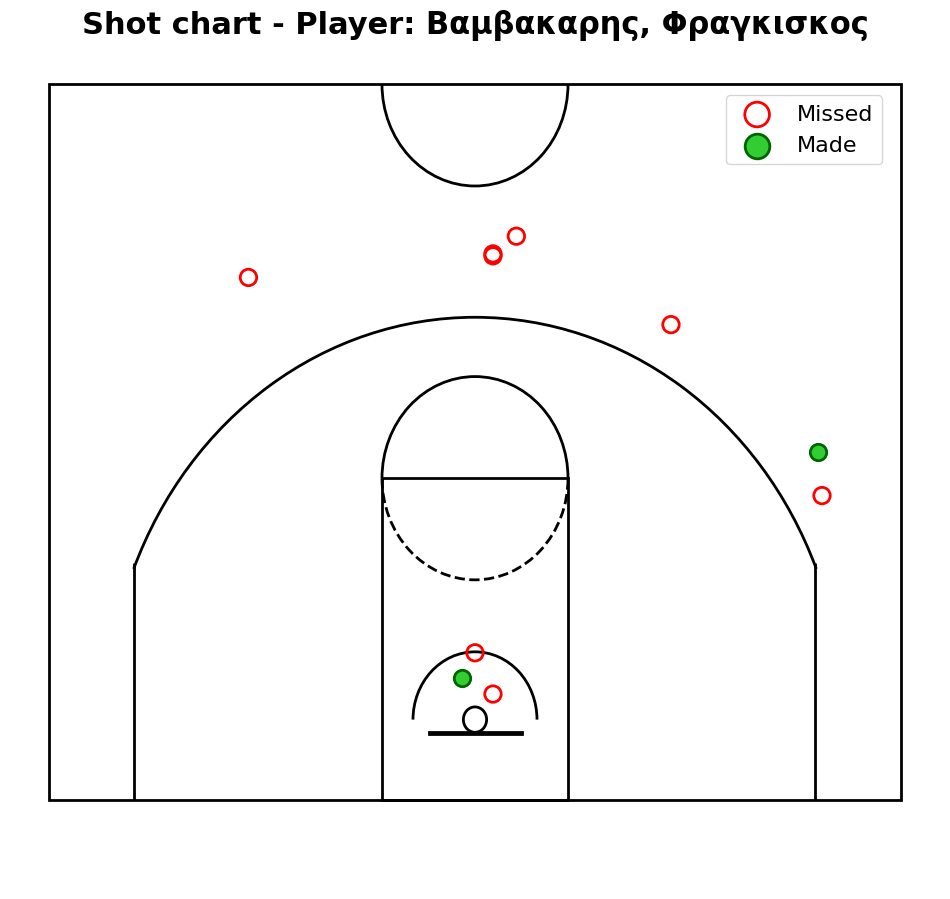

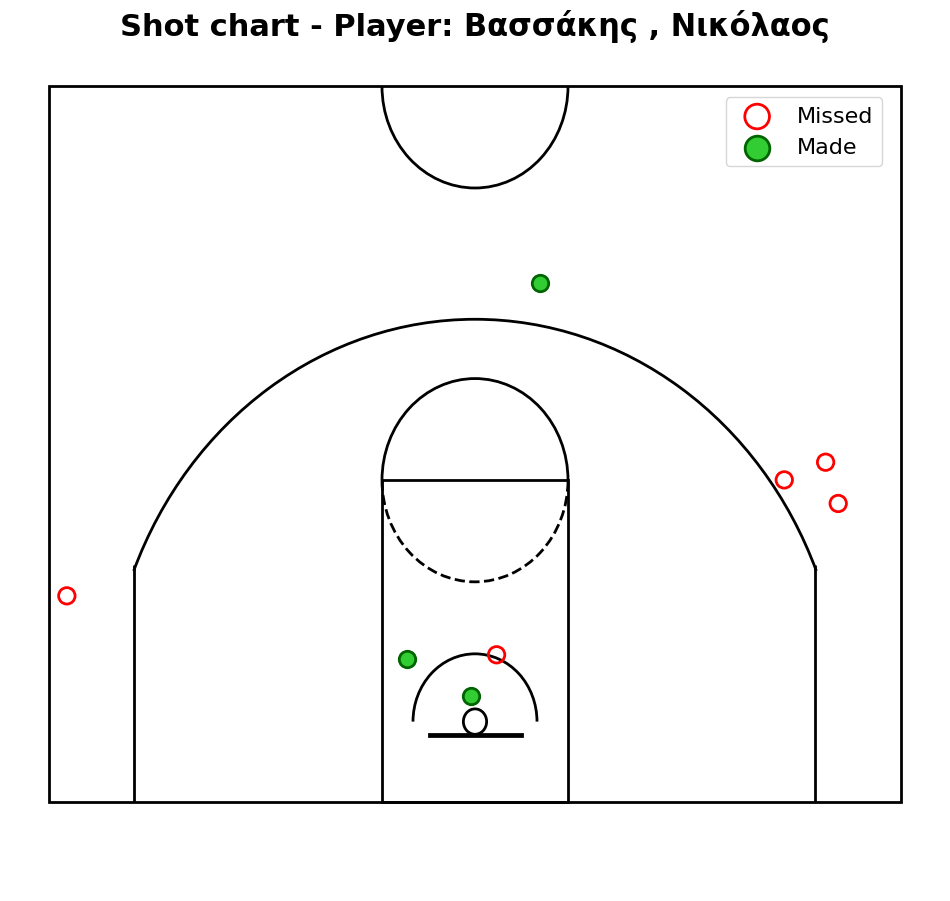

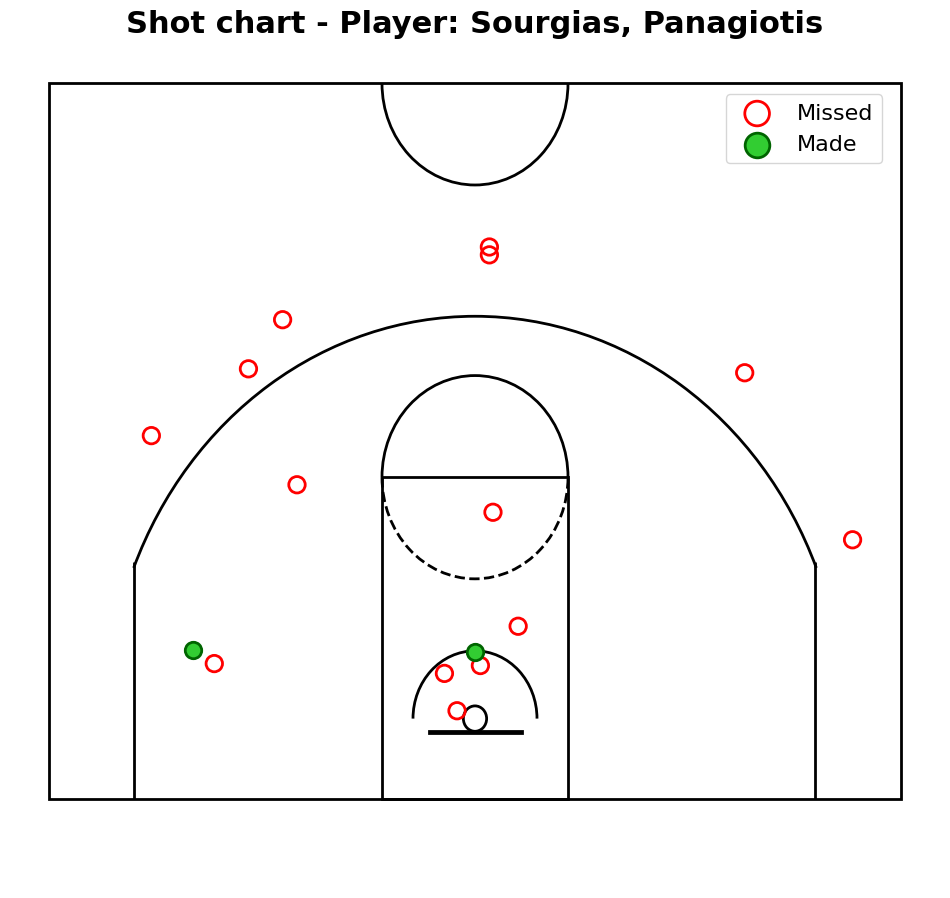

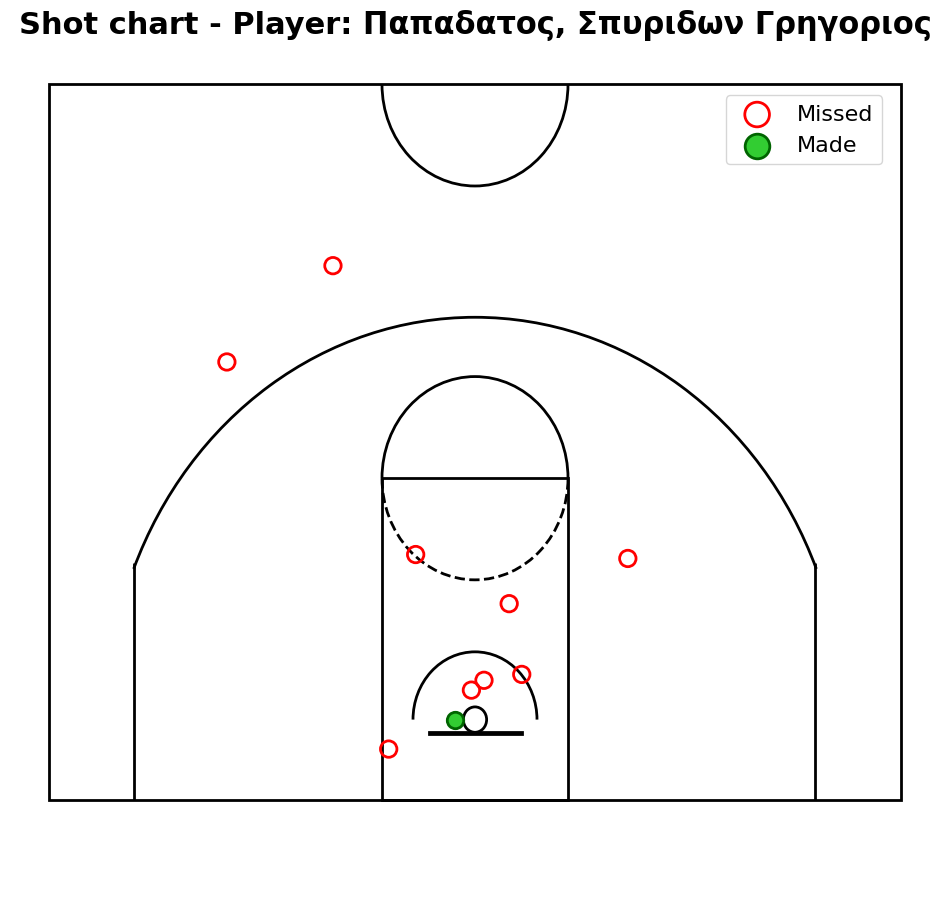

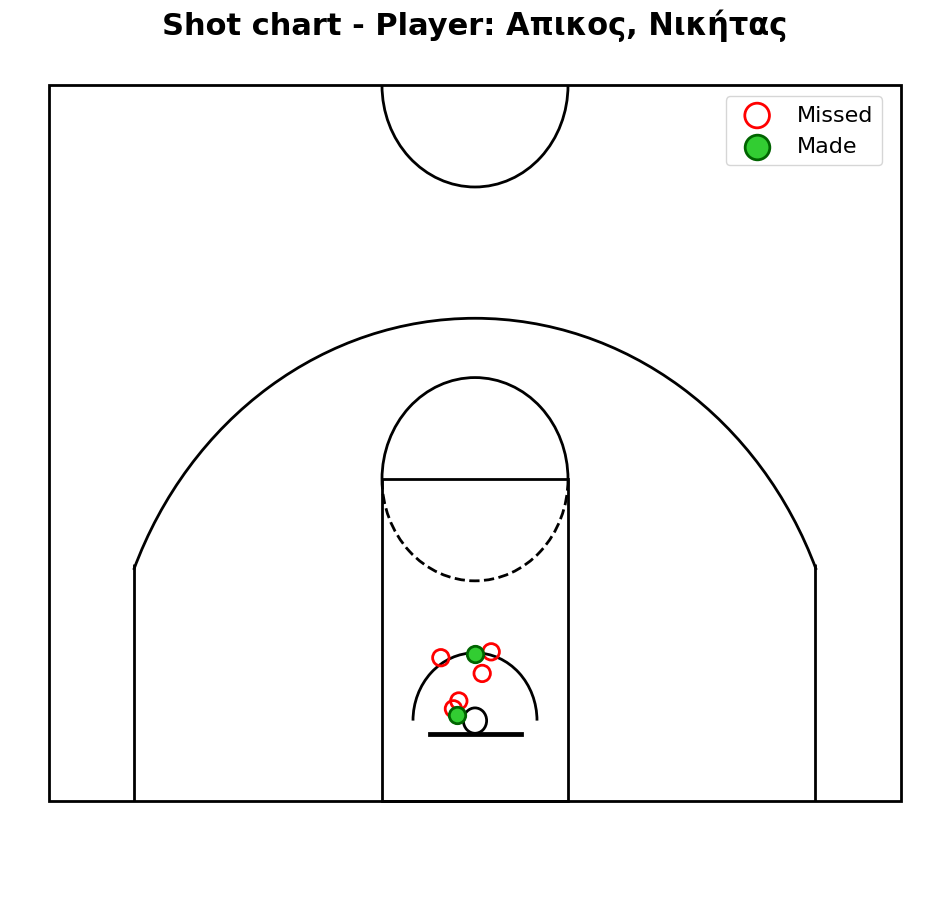

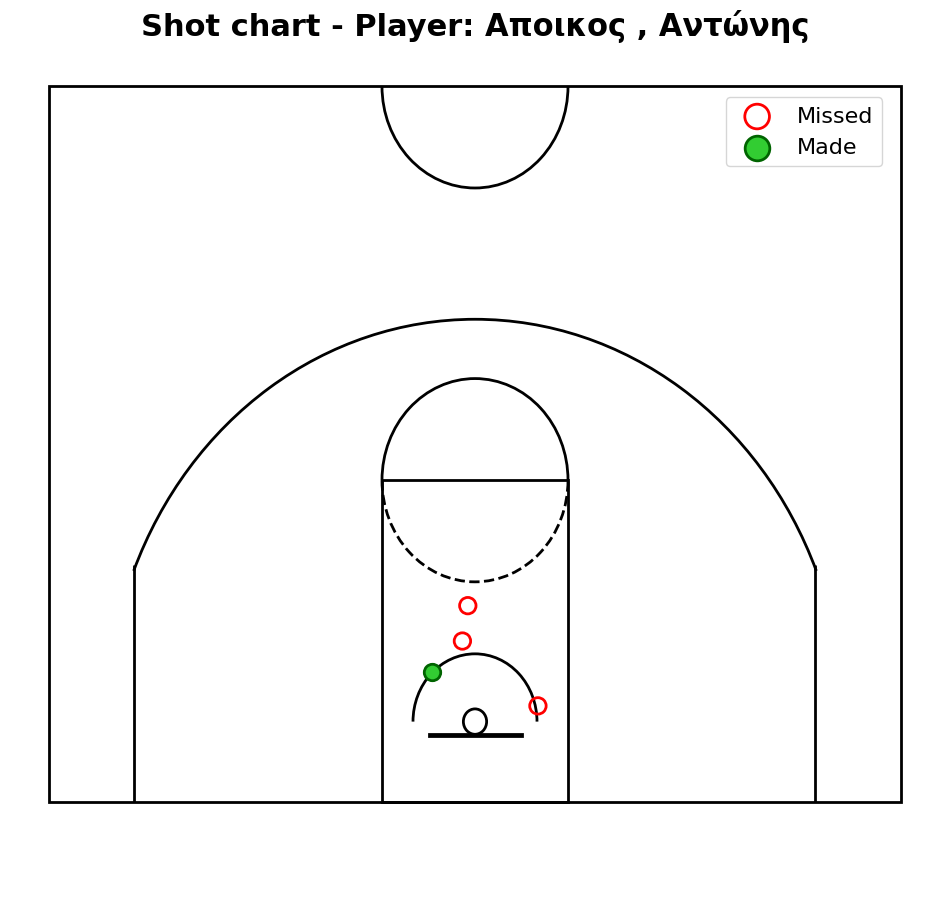

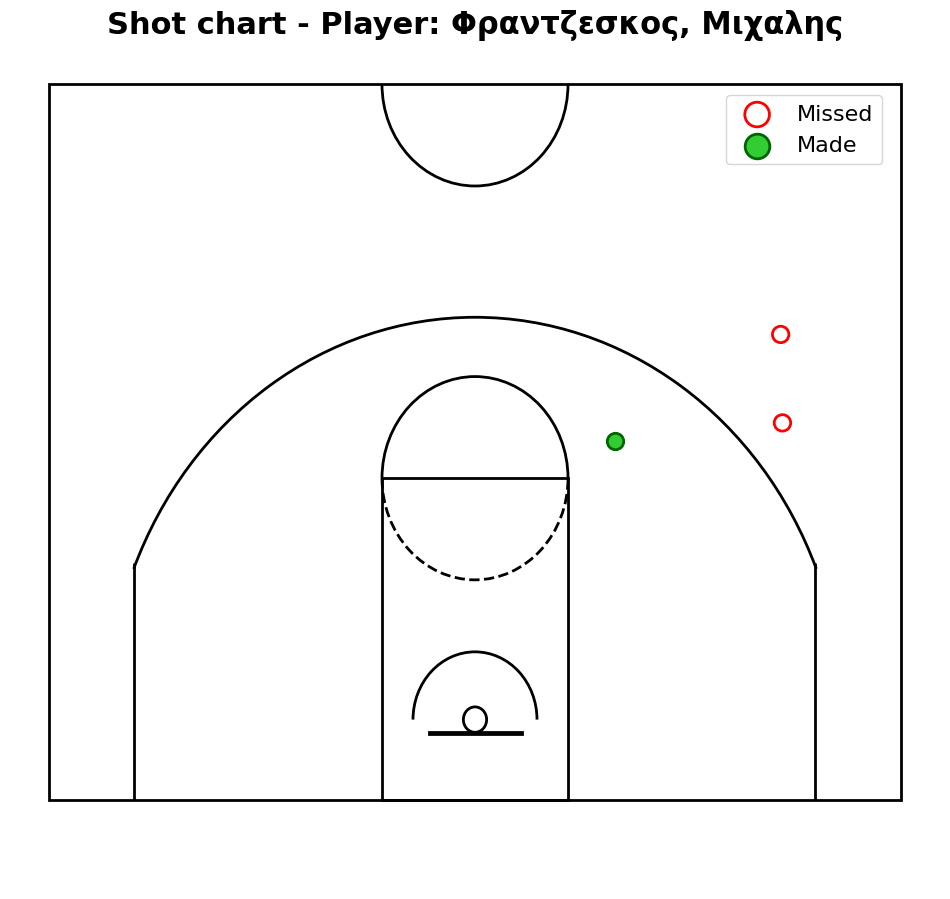

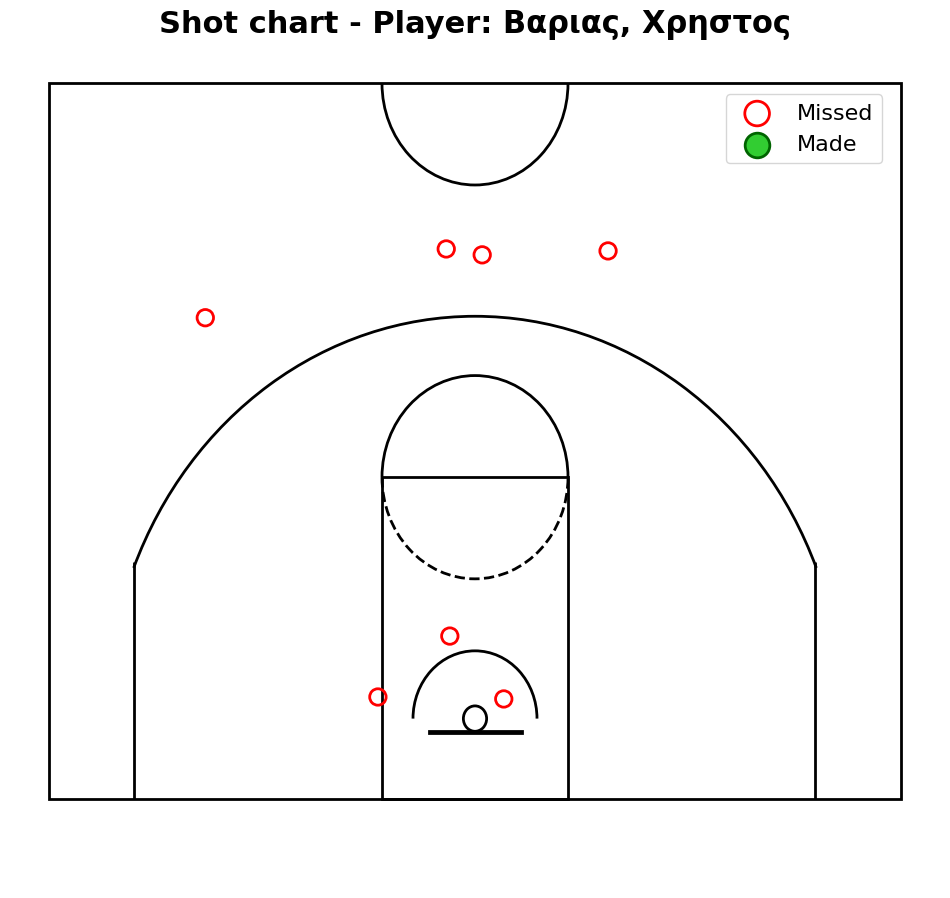

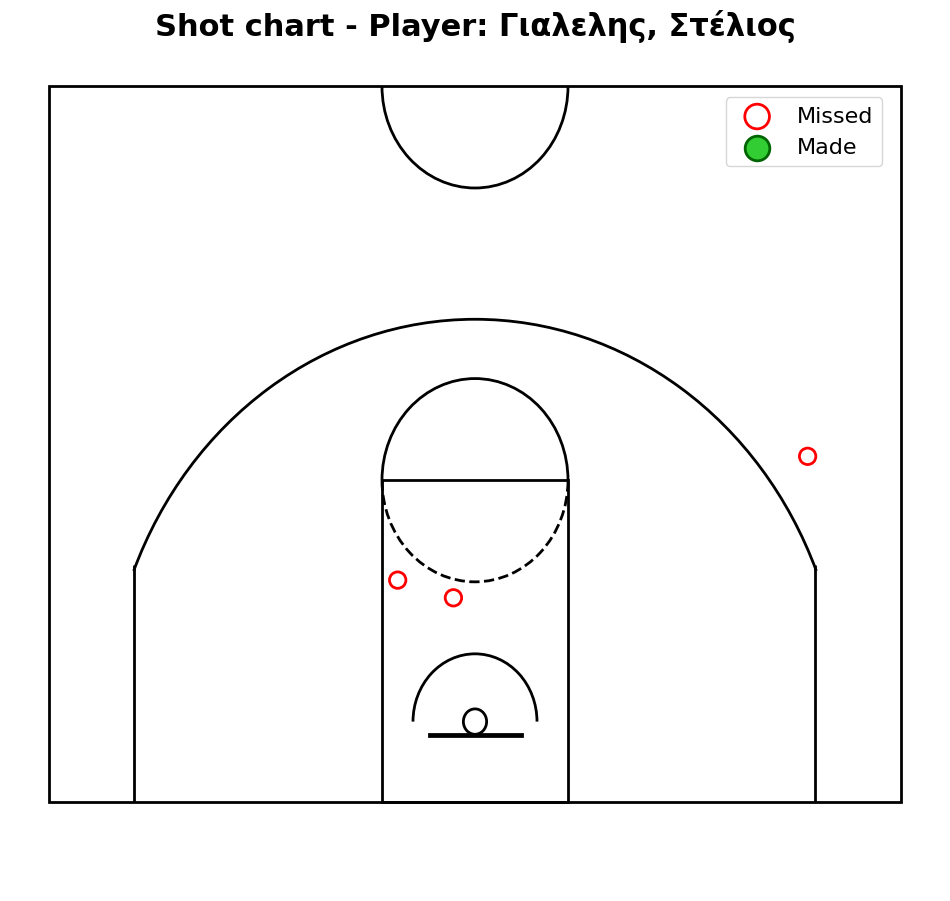

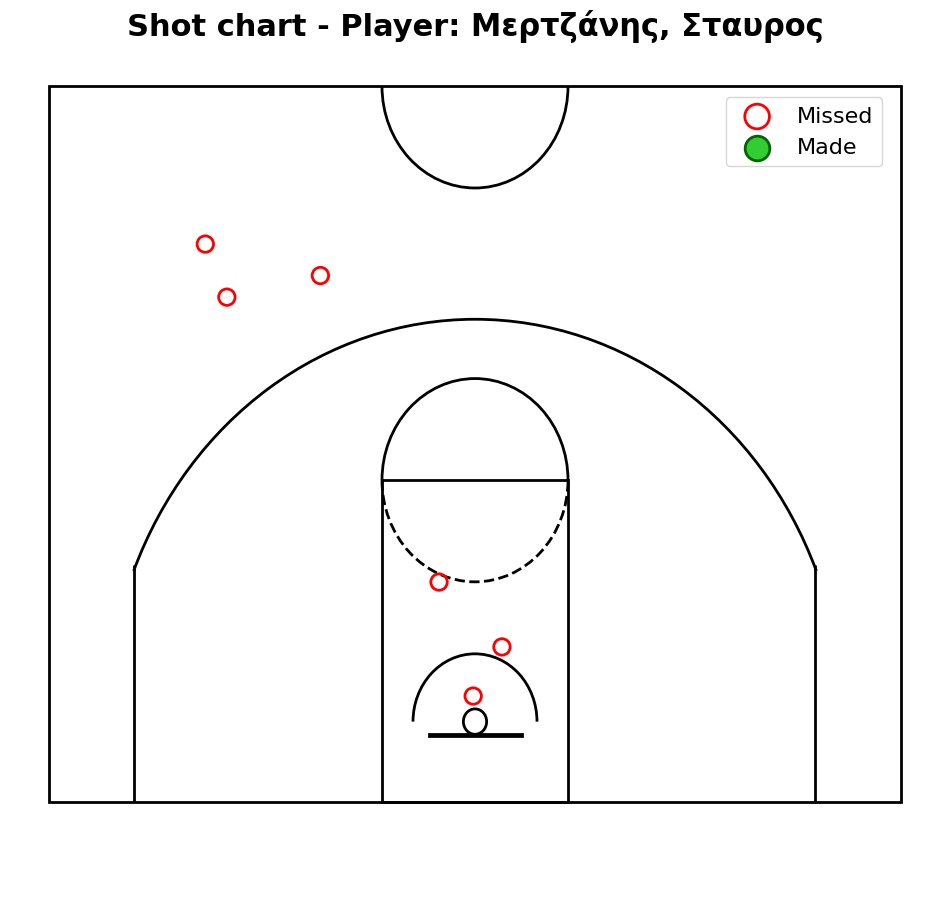

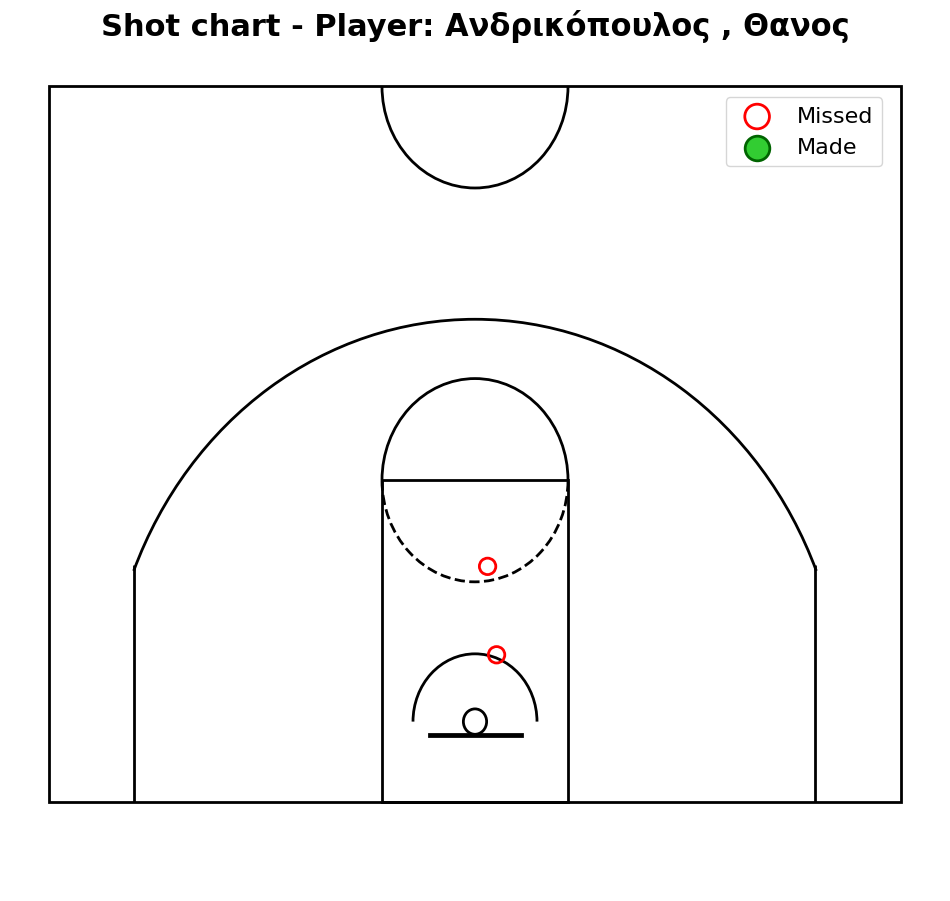

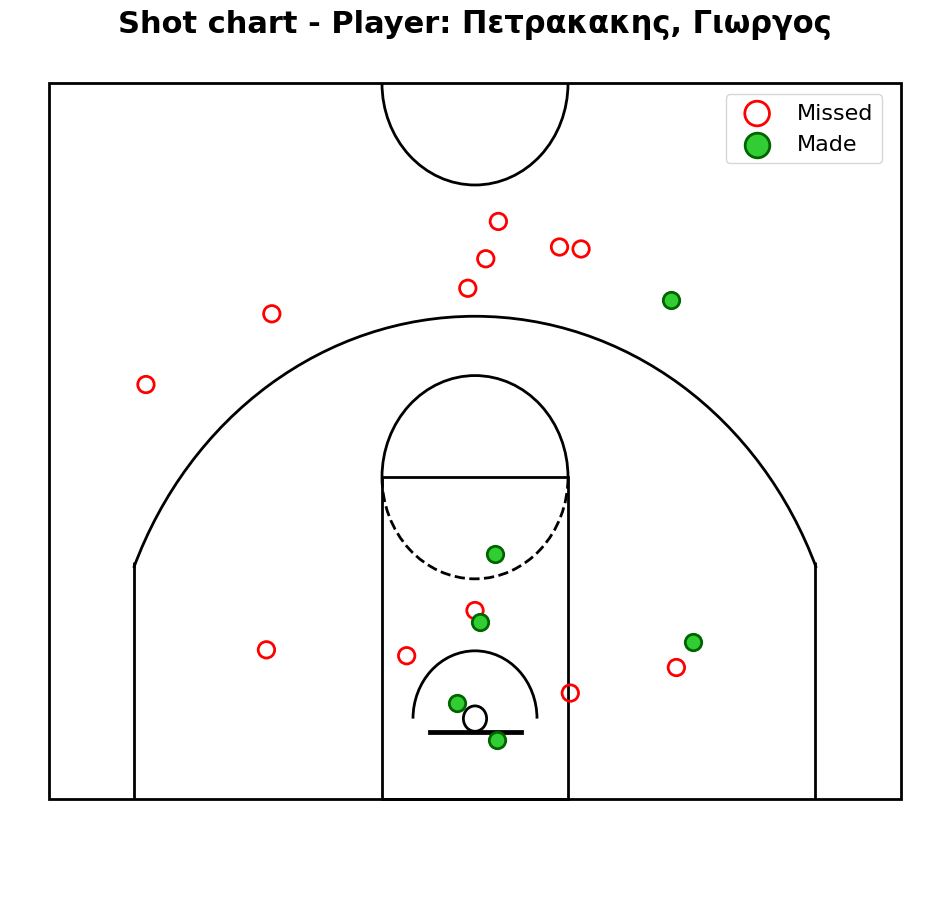

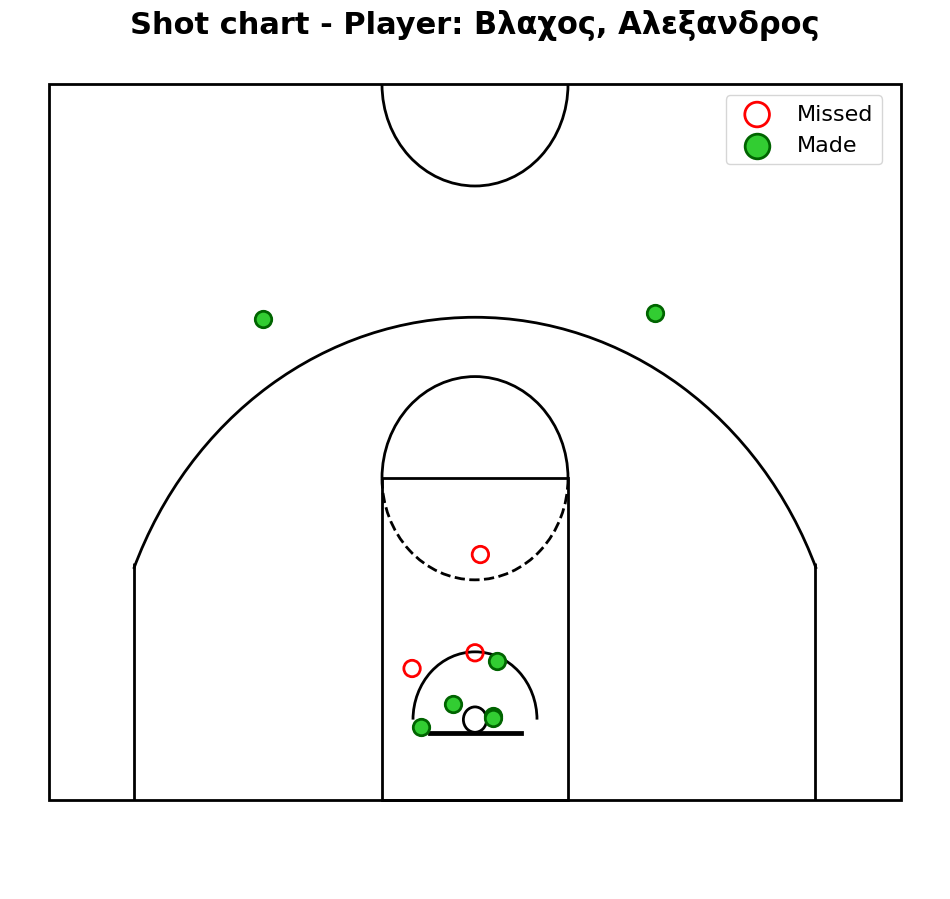

In [12]:
for team, roster in [("away", away_players), ("home", home_players)]:
    for pid, name in roster.items():
        df = get_shots(soup, pid)
        if df.empty:
            continue
        plot_shot_chart(df, name, team)


## Plot the shot - chart of a player

The data are already parsed and stored in a CSV file:
data/processed/shots_master.csv

The goal is to plot aggregated shots in a chart of a specific player


In [13]:
from pathlib import Path
import pandas as pd

SHOTS_PATH = Path("../data/processed/shots_master.csv")
shots_df = pd.read_csv(SHOTS_PATH)
shots_df.head()


,DATE,SEASON,TEAM,OPPONENT,TEAM_SIDE,PLAYER_ID,PLAYER,PERIOD,SHOT_TYPE,MADE,SHOT_INDEX,RAW_X,RAW_Y,COURT_X,COURT_Y
0,20/11/2024,2024-25,Proteas Dads,Clicka BC,home,103,Christos Paraskeuas,1,2PT,True,0,47,187,-73.08,-10.44
1,20/11/2024,2024-25,Proteas Dads,Clicka BC,home,103,Christos Paraskeuas,1,2PT,False,1,75,188,-71.92,22.04
2,20/11/2024,2024-25,Proteas Dads,Clicka BC,home,103,Christos Paraskeuas,1,2PT,True,2,52,249,-1.16,-4.64
3,20/11/2024,2024-25,Proteas Dads,Clicka BC,home,103,Christos Paraskeuas,2,2PT,False,3,47,305,63.80,-10.44
4,20/11/2024,2024-25,Proteas Dads,Clicka BC,home,103,Christos Paraskeuas,3,2PT,True,4,90,250,0.00,39.44


In [14]:
SEASON = "2025-26"
PLAYER_NAME = "Nikolaos Vassakis"

player_df = shots_df[(shots_df["SEASON"] == SEASON) & (shots_df["PLAYER"] == PLAYER_NAME)]
player_df


,DATE,SEASON,TEAM,OPPONENT,TEAM_SIDE,PLAYER_ID,PLAYER,PERIOD,SHOT_TYPE,MADE,SHOT_INDEX,RAW_X,RAW_Y,COURT_X,COURT_Y
8988,13/03/2026,2025-26,Unleash The Clowns,Glyfathers,away,302,Nikolaos Vassakis,1,2PT,False,0,913,228,25.52,35.96
8989,13/03/2026,2025-26,Unleash The Clowns,Glyfathers,away,302,Nikolaos Vassakis,2,2PT,True,1,910,250,0.00,39.44
8990,13/03/2026,2025-26,Unleash The Clowns,Glyfathers,away,302,Nikolaos Vassakis,2,2PT,False,2,836,255,-5.80,125.28
8991,13/03/2026,2025-26,Unleash The Clowns,Glyfathers,away,302,Nikolaos Vassakis,3,2PT,False,3,941,240,11.60,3.48
8992,13/03/2026,2025-26,Unleash The Clowns,Glyfathers,away,302,Nikolaos Vassakis,4,2PT,False,4,940,104,169.36,4.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72188,05/05/2026,2025-26,Unleash The Clowns,Proteas Dads,home,302,Nikolaos Vassakis,2,2PT,True,3,150,238,-13.92,109.04
72189,05/05/2026,2025-26,Unleash The Clowns,Proteas Dads,home,302,Nikolaos Vassakis,2,2PT,True,4,90,250,0.00,39.44
72190,05/05/2026,2025-26,Unleash The Clowns,Proteas Dads,home,302,Nikolaos Vassakis,1,3PT,False,5,226,113,-158.92,197.20
72191,05/05/2026,2025-26,Unleash The Clowns,Proteas Dads,home,302,Nikolaos Vassakis,2,3PT,False,6,199,417,193.72,165.88


In [15]:
threes = shots_df[(shots_df["PLAYER"] == "Nikolaos Vassakis") & (shots_df["SEASON"] == "2025-26") & (shots_df["SHOT_TYPE"] == "3PT")]

made = threes["MADE"].sum()
attempts = len(threes)
pct = made / attempts * 100 if attempts else 0

print(f"3PT: {made}/{attempts} ({pct:.1f}%)")


3PT: 11/40 (27.5%)


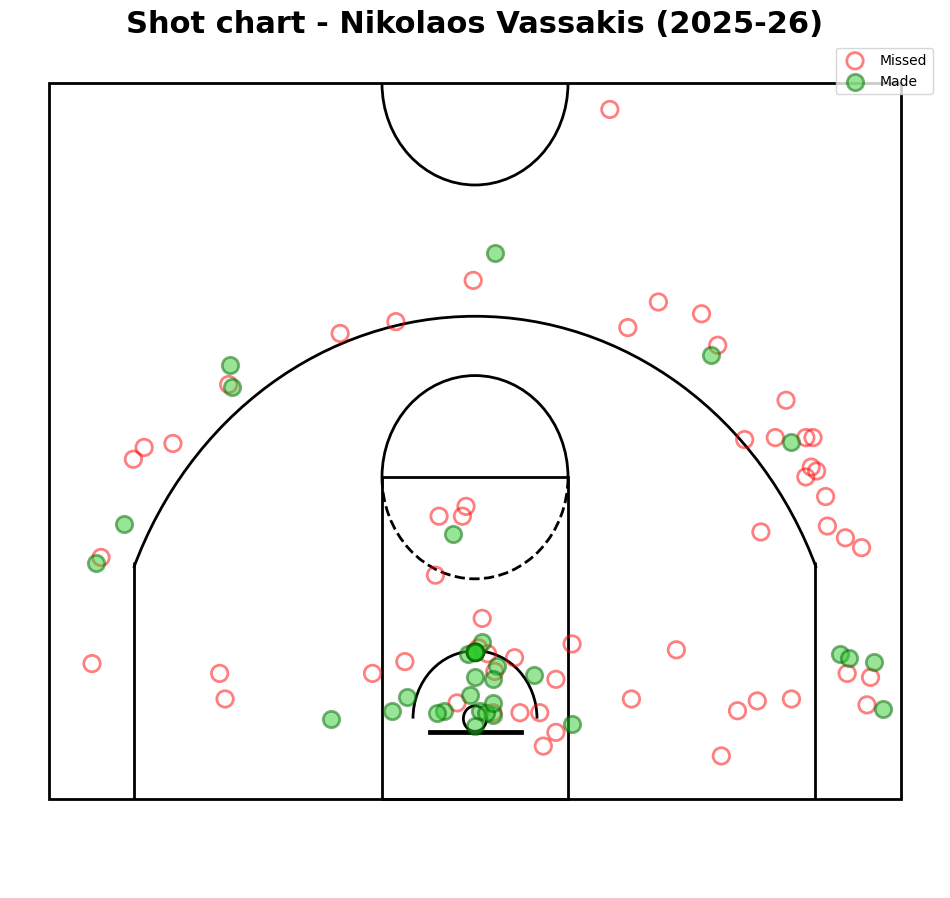

In [16]:
SEASON = "2025-26"
# SEASON = "2024-25"
PLAYER_NAME = "Nikolaos Vassakis"

player_df = shots_df[(shots_df["SEASON"] == SEASON) & (shots_df["PLAYER"] == PLAYER_NAME)]

made = player_df[player_df["MADE"]]
missed = player_df[~player_df["MADE"]]

fig, ax = plt.subplots(figsize=(12, 11))
draw_court(ax, outer_lines=True)

ax.scatter(missed["COURT_X"], missed["COURT_Y"], facecolors="none", edgecolors="red",
           s=140, linewidths=2, alpha=0.5, label="Missed")
ax.scatter(made["COURT_X"], made["COURT_Y"], facecolors="limegreen", edgecolors="darkgreen",
           s=140, linewidths=2, alpha=0.5, label="Made")

ax.set_xlim(-300, 300)
ax.set_ylim(-100, 400)
ax.set_title(f"Shot chart - {PLAYER_NAME} ({SEASON})", fontsize=22, fontweight="bold")
ax.legend(loc="upper right")
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
plt.show()


## Shot quality charts

Now its the time to explore where a player stands within the league.
By splitting the half-court into areas, we can group the shots into percentages and compare
to the league averages into a heat map.
Another useful information would be the volume of the shots to have an idea of how
frequently a player shoots from that specific region to estimate if he really prefers to shoot
from there.

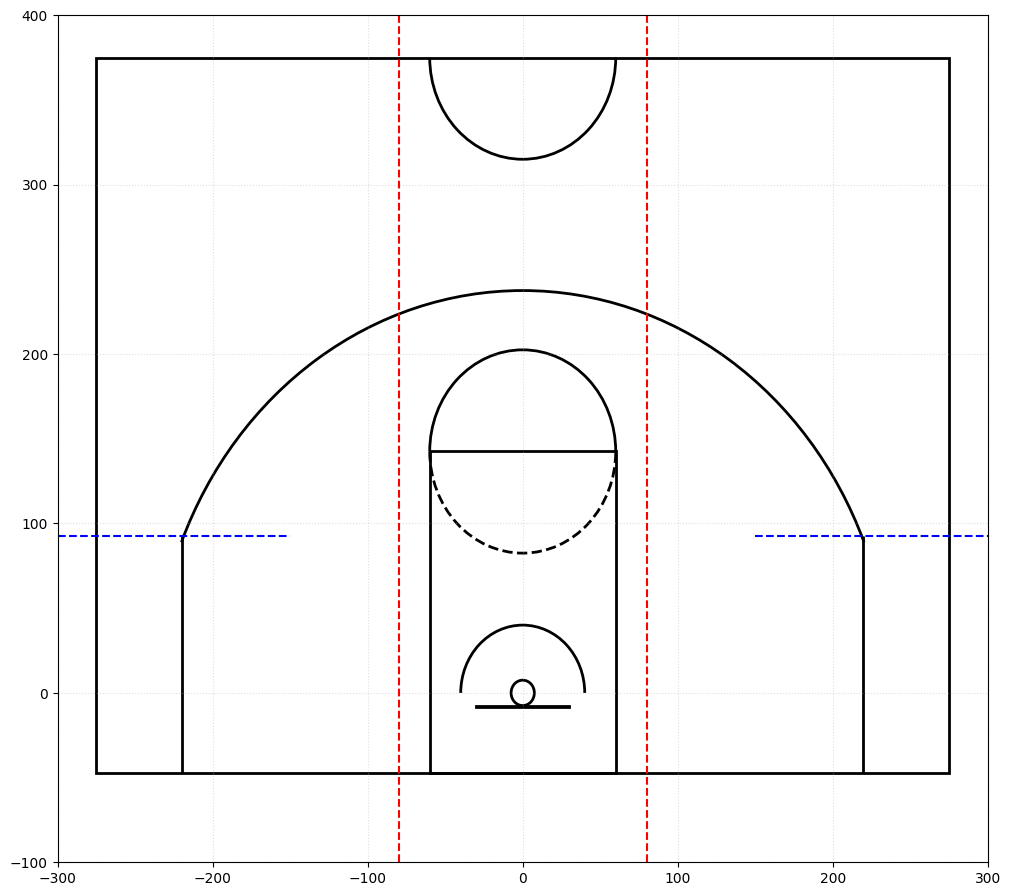

In [17]:
## Draw lines to define 3pt regions

fig, ax = plt.subplots(figsize=(12, 11))
draw_court(ax, outer_lines=True)

# corner 3 boundary
ax.axhline(y=92.5, xmin=0, xmax=0.25, color='blue', lw=1.5, linestyle='--')   
ax.axhline(y=92.5, xmin=0.75, xmax=1, color='blue', lw=1.5, linestyle='--')   

# 2 verticals
ax.axvline(x=-80, color='red', lw=1.5, linestyle='--')  
ax.axvline(x=80,  color='red', lw=1.5, linestyle='--')   

ax.set_xlim(-300, 300)
ax.set_ylim(-100, 400)
ax.grid(True, linestyle=':', alpha=0.4)
plt.show()


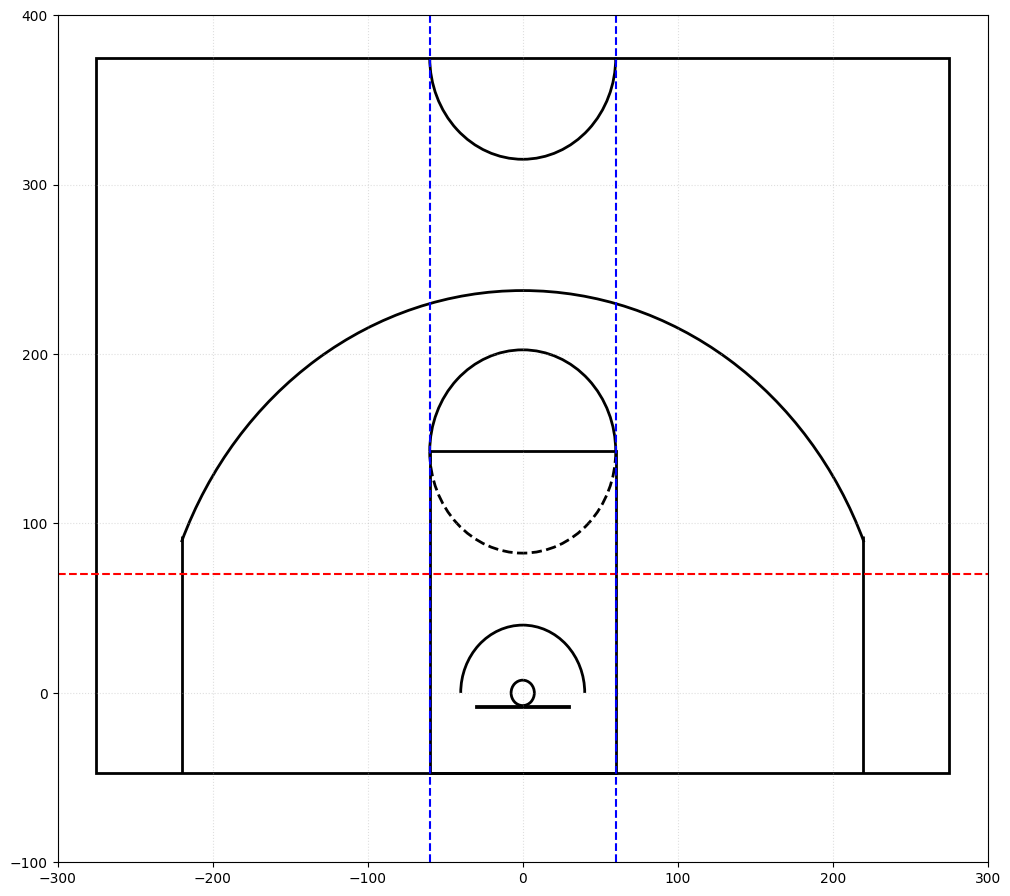

In [18]:
## Draw lines to define 2pt regions

fig, ax = plt.subplots(figsize=(12, 11))
draw_court(ax, outer_lines=True)

# horizontal
ax.axhline(y=70, color='red', lw=1.5, linestyle='--')

# verticals 
ax.axvline(x=-60, color='blue', lw=1.5, linestyle='--')
ax.axvline(x=60,  color='blue', lw=1.5, linestyle='--')


ax.set_xlim(-300, 300)
ax.set_ylim(-100, 400)
ax.grid(True, linestyle=':', alpha=0.4)
plt.show()


In [19]:
# Define the regions
def get_region(court_x, court_y, shot_type):
    if shot_type == "2PT":
        if -60 <= court_x <= 60 and court_y < 70:
            return "Box"
        elif -60 <= court_x <= 60 and court_y >= 70:
            return "Top Mid-Range"
        elif court_x < -60:
            return "Left Side"
        elif court_x > 60:
            return "Right Side"
        else:
                return "Undefined"

    else:  # 3PT
        if court_x < -220 and court_y < 92.5:
            return "Left Corner 3"
        elif court_x > 220 and court_y < 92.5:
            return "Right Corner 3"
        elif court_x < -80:
            return "Left-45 3pt"
        elif court_x > 80:
            return "Right-45 3pt"
        elif -80 <= court_x <= 80 and court_y >= 92.5:
            return "Top 3pt"
        else:
            return "Undefined"


In [20]:
# Add REGION column to shots_df
shots_df["REGION"] = shots_df.apply(
    lambda row: get_region(row["COURT_X"], row["COURT_Y"], row["SHOT_TYPE"]), axis=1
)
shots_df["REGION"].value_counts()


REGION
Box               25047
Left Side          8970
Right-45 3pt       8825
Left-45 3pt        8592
Right Side         7952
Top Mid-Range      5499
Top 3pt            4250
Left Corner 3      1670
Right Corner 3     1584
Undefined             8
Name: count, dtype: int64

In [21]:
shots_df[shots_df["REGION"] == "Undefined"][["COURT_X", "COURT_Y", "SHOT_TYPE", "PLAYER", "DATE"]]

# Drop the undefined shots
shots_df = shots_df[shots_df["REGION"] != "Undefined"]

In [22]:
# Check whether something went wrong in the transformation from SVG to court coordinates
for region, group in shots_df.groupby("REGION"):
    counts = group["SHOT_TYPE"].value_counts()
    twos = counts.get("2PT", 0)
    threes = counts.get("3PT", 0)
    print(f"{region}: 2PT={twos}, 3PT={threes}")


Box: 2PT=25047, 3PT=0
Left Corner 3: 2PT=0, 3PT=1670
Left Side: 2PT=8970, 3PT=0
Left-45 3pt: 2PT=0, 3PT=8592
Right Corner 3: 2PT=0, 3PT=1584
Right Side: 2PT=7952, 3PT=0
Right-45 3pt: 2PT=0, 3PT=8825
Top 3pt: 2PT=0, 3PT=4250
Top Mid-Range: 2PT=5499, 3PT=0


In [23]:
SEASON = "2025-26"
PLAYER_NAME = "Nikolaos Vassakis"
# SEASON = "2023-24"

player_df = shots_df[(shots_df["PLAYER"] == PLAYER_NAME) & (shots_df["SEASON"] == SEASON)]

results = []
for region, group in player_df.groupby("REGION"):
    attempts = len(group)
    made = group["MADE"].sum()
    pct = made / attempts * 100 if attempts > 0 else 0
    results.append({"REGION": region, "ATTEMPTS": attempts, "MADE": made, "FG_PCT": round(pct, 1)})

region_df = pd.DataFrame(results).sort_values("ATTEMPTS", ascending=False)
region_df


,REGION,ATTEMPTS,MADE,FG_PCT
0,Box,37,22,59.5
6,Right-45 3pt,19,2,10.5
3,Left-45 3pt,9,3,33.3
5,Right Side,9,1,11.1
4,Right Corner 3,7,4,57.1
8,Top Mid-Range,5,1,20.0
2,Left Side,4,1,25.0
7,Top 3pt,3,1,33.3
1,Left Corner 3,2,1,50.0


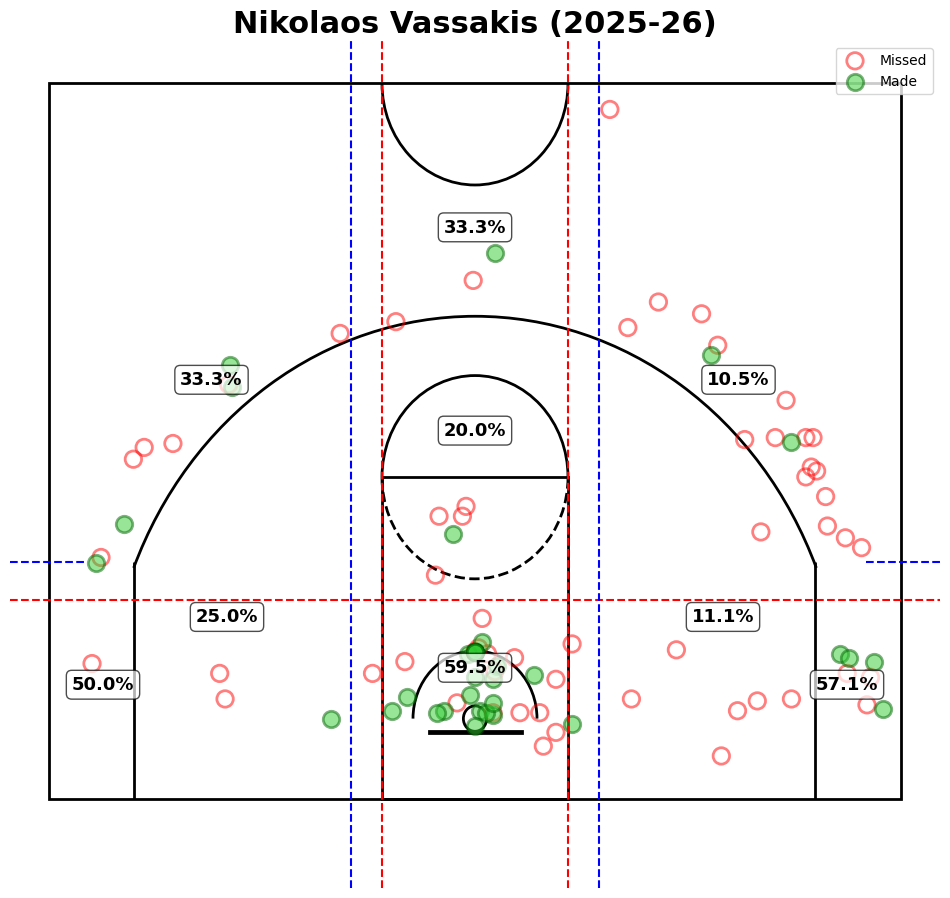

In [24]:
fig, ax = plt.subplots(figsize=(12, 11))
draw_court(ax, outer_lines=True)

# shots
made = player_df[player_df["MADE"]]
missed = player_df[~player_df["MADE"]]

ax.scatter(missed["COURT_X"], missed["COURT_Y"], facecolors="none", edgecolors="red",
           s=140, linewidths=2, alpha=0.5, label="Missed")
ax.scatter(made["COURT_X"], made["COURT_Y"], facecolors="limegreen", edgecolors="darkgreen",
           s=140, linewidths=2, alpha=0.5, label="Made")

# 2PT boundaries
ax.axhline(y=70, color='red', lw=1.5, linestyle='--')
ax.axvline(x=-60, color='red', lw=1.5, linestyle='--')
ax.axvline(x=60,  color='red', lw=1.5, linestyle='--')

# 3PT boundaries
ax.axhline(y=92.5, xmin=0, xmax=0.08, color='blue', lw=1.5, linestyle='--')
ax.axhline(y=92.5, xmin=0.92, xmax=1,  color='blue', lw=1.5, linestyle='--')
ax.axvline(x=-80, color='blue', lw=1.5, linestyle='--')
ax.axvline(x=80,  color='blue', lw=1.5, linestyle='--')

ax.set_xlim(-300, 300)
ax.set_ylim(-100, 400)
ax.set_title(f"{PLAYER_NAME} ({SEASON})", fontsize=22, fontweight="bold")
ax.legend(loc="upper right")
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

REGION_CENTERS = {
    "Box":            (0,    30),
    "Left Side":      (-160, 60),
    "Right Side":     (160,  60),
    "Top Mid-Range":  (0,    170),
    "Left Corner 3":  (-240, 20),
    "Left-45 3pt":    (-170, 200),
    "Top 3pt":        (0,    290),
    "Right-45 3pt":   (170,  200),
    "Right Corner 3": (240,  20),
}

for _, row in region_df.iterrows():
    cx, cy = REGION_CENTERS[row["REGION"]]
    ax.text(cx, cy, f"{row['FG_PCT']}%",
            ha="center", va="center", fontsize=13, fontweight="bold", color="black",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

plt.show()


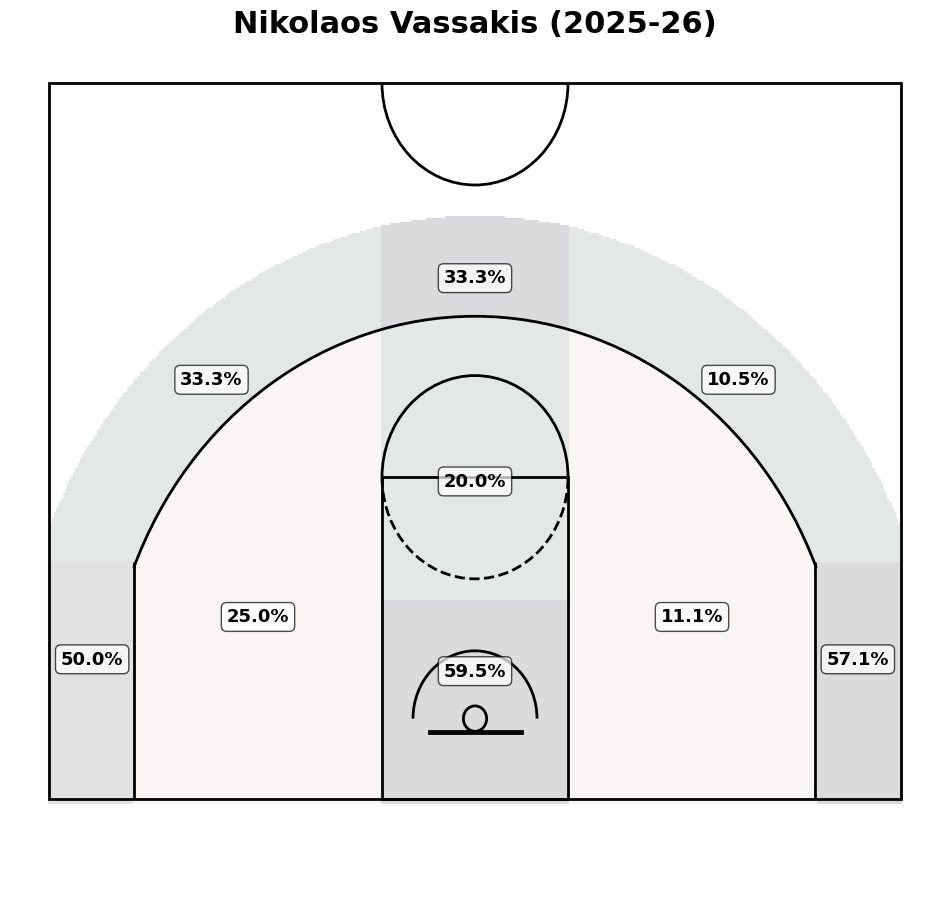

In [25]:
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

x_vals = np.linspace(-275, 275, 400)
y_vals = np.linspace(-50, 400, 400)
X, Y = np.meshgrid(x_vals, y_vals)

dist = np.sqrt(X**2 + Y**2)

arc_radius = 237.5
in_corner_left  = (X < -220) & (Y < 92.5)
in_corner_right = (X > 220)  & (Y < 92.5)
outside_arc     = (dist > arc_radius) | in_corner_left | in_corner_right
inside_arc      = ~outside_arc
outer_limit     = dist <= arc_radius * 1.25

region_grid = np.full(X.shape, -1)

# 2PT regions
region_grid[inside_arc & (X >= -60) & (X <= 60) & (Y < 70)]  = 0  
region_grid[inside_arc & (X >= -60) & (X <= 60) & (Y >= 70)] = 3  
region_grid[inside_arc & (X < -60)]                           = 1  
region_grid[inside_arc & (X > 60)]                            = 2  

# 3PT regions
outside_not_corner = outside_arc & ~in_corner_left & ~in_corner_right & outer_limit
region_grid[in_corner_left]                                                              = 4  
region_grid[in_corner_right]                                                             = 5  
region_grid[outside_not_corner & (X < -60)]                                              = 6 
region_grid[outside_not_corner & (X > 60)]                                               = 7  
region_grid[outside_not_corner & (X >= -60) & (X <= 60) & (Y >= 92.5)]                  = 8 

region_colors = ["#969A9B", "#EFE4E3", "#EFE4E3", "#AFBFB9",
                 "#A8ADAE", "#969A9B", "#AFBFB9", "#AFBFB9", "#969A9B"]
# region_colors = ["#AFBFB9", "#EFE4E3", "#EFE4E3", "#6F7172",
#                  "#AFBFB9", "#AFBFB9", "#6F7172", "#6F7172", "#AFBFB9"]

                 
cmap = ListedColormap(region_colors)
norm = BoundaryNorm([-0.5 + i for i in range(10)], cmap.N)

fig, ax = plt.subplots(figsize=(12, 11))
region_masked = np.ma.masked_where(region_grid == -1, region_grid)

ax.pcolormesh(X, Y, region_masked, cmap=cmap, norm=norm, alpha=0.35, zorder=0)
draw_court(ax, outer_lines=True)

ax.set_xlim(-300, 300)
ax.set_ylim(-100, 400)
ax.set_title(f"{PLAYER_NAME} ({SEASON})", fontsize=22, fontweight="bold")
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

REGION_CENTERS = {
    "Box":            (0,    28),
    "Left Side":      (-140, 60),
    "Right Side":     (140,  60),
    "Top Mid-Range":  (0,    140),
    "Left Corner 3":  (-247, 35),
    "Left-45 3pt":    (-170, 200),
    "Top 3pt":        (0,    260),
    "Right-45 3pt":   (170,  200),
    "Right Corner 3": (247,  35),
}

for _, row in region_df.iterrows():
    cx, cy = REGION_CENTERS[row["REGION"]]
    ax.text(cx, cy, f"{row['FG_PCT']}%",
            ha="center", va="center", fontsize=13, fontweight="bold", color="black",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

plt.show()


In [31]:
REGION_CENTERS = {
    "Box":            (0,    28),
    "Left Side":      (-140, 60),
    "Right Side":     (140,  60),
    "Top Mid-Range":  (0,    140),
    "Left Corner 3":  (-247, 35),
    "Left-45 3pt":    (-170, 200),
    "Top 3pt":        (0,    260),
    "Right-45 3pt":   (170,  200),
    "Right Corner 3": (247,  35),
}

In [26]:
SEASON = "2025-26"
# SEASON = "2023-24"

league_df = shots_df[shots_df["SEASON"] == SEASON]

results = []
for region, group in league_df.groupby("REGION"):
    attempts = len(group)
    made = group["MADE"].sum()
    pct = made / attempts * 100 if attempts > 0 else 0
    results.append({"REGION": region,  "LEAGUE_MADE": made, "LEAGUE_ATTEMPTS": attempts, "LEAGUE_PCT": round(pct, 1)})

league_avg_df = pd.DataFrame(results).sort_values("LEAGUE_ATTEMPTS", ascending=False)
league_avg_df


,REGION,LEAGUE_MADE,LEAGUE_ATTEMPTS,LEAGUE_PCT
0,Box,3648,7281,50.1
3,Left-45 3pt,535,2241,23.9
2,Left Side,660,2240,29.5
6,Right-45 3pt,473,2197,21.5
5,Right Side,593,2147,27.6
8,Top Mid-Range,488,1817,26.9
7,Top 3pt,292,1378,21.2
4,Right Corner 3,198,714,27.7
1,Left Corner 3,143,662,21.6


In [27]:
# Calculate the league's averages for each region
from matplotlib.colors import TwoSlopeNorm

comparison = region_df.merge(
    league_avg_df[["REGION", "LEAGUE_PCT"]], on="REGION"
)
comparison["VS_LEAGUE"] = comparison["FG_PCT"] - comparison["LEAGUE_PCT"]
comparison


,REGION,ATTEMPTS,MADE,FG_PCT,LEAGUE_PCT,VS_LEAGUE
0,Box,37,22,59.5,50.1,9.4
1,Right-45 3pt,19,2,10.5,21.5,-11.0
2,Left-45 3pt,9,3,33.3,23.9,9.4
3,Right Side,9,1,11.1,27.6,-16.5
4,Right Corner 3,7,4,57.1,27.7,29.4
5,Top Mid-Range,5,1,20.0,26.9,-6.9
6,Left Side,4,1,25.0,29.5,-4.5
7,Top 3pt,3,1,33.3,21.2,12.1
8,Left Corner 3,2,1,50.0,21.6,28.4


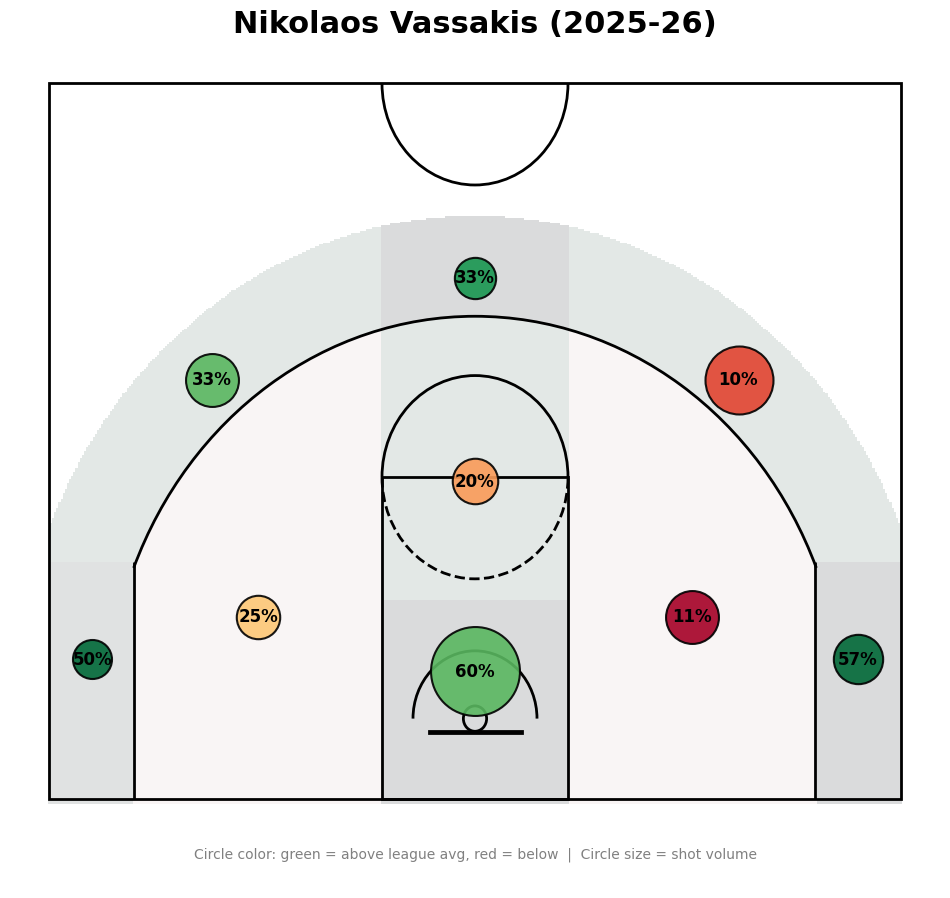

In [ ]:
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

x_vals = np.linspace(-275, 275, 400)
y_vals = np.linspace(-50, 400, 400)
X, Y = np.meshgrid(x_vals, y_vals)

dist = np.sqrt(X**2 + Y**2)

arc_radius = 237.5
in_corner_left  = (X < -220) & (Y < 92.5)
in_corner_right = (X > 220)  & (Y < 92.5)
outside_arc     = (dist > arc_radius) | in_corner_left | in_corner_right
inside_arc      = ~outside_arc
outer_limit     = dist <= arc_radius * 1.25

region_grid = np.full(X.shape, -1)

# 2PT regions
region_grid[inside_arc & (X >= -60) & (X <= 60) & (Y < 70)]  = 0  # Box
region_grid[inside_arc & (X >= -60) & (X <= 60) & (Y >= 70)] = 3  # Top Mid-Range
region_grid[inside_arc & (X < -60)]                           = 1  # Left Side
region_grid[inside_arc & (X > 60)]                            = 2  # Right Side

# 3PT regions
outside_not_corner = outside_arc & ~in_corner_left & ~in_corner_right & outer_limit
region_grid[in_corner_left]                                                              = 4  # Left Corner 3
region_grid[in_corner_right]                                                             = 5  # Right Corner 3
region_grid[outside_not_corner & (X < -60)]                                              = 6  # Left-45 3pt
region_grid[outside_not_corner & (X > 60)]                                               = 7  # Right-45 3pt
region_grid[outside_not_corner & (X >= -60) & (X <= 60) & (Y >= 92.5)]                  = 8  # Top 3pt

region_colors = ["#969A9B", "#EFE4E3", "#EFE4E3", "#AFBFB9",
                 "#A8ADAE", "#969A9B", "#AFBFB9", "#AFBFB9", "#969A9B"]
# region_colors = ["#AFBFB9", "#EFE4E3", "#EFE4E3", "#6F7172",
#                  "#AFBFB9", "#AFBFB9", "#6F7172", "#6F7172", "#AFBFB9"]

                 
cmap = ListedColormap(region_colors)
norm = BoundaryNorm([-0.5 + i for i in range(10)], cmap.N)

fig, ax = plt.subplots(figsize=(12, 11))
region_masked = np.ma.masked_where(region_grid == -1, region_grid)

ax.pcolormesh(X, Y, region_masked, cmap=cmap, norm=norm, alpha=0.35, zorder=0)
draw_court(ax, outer_lines=True)

ax.set_xlim(-300, 300)
ax.set_ylim(-100, 400)
ax.set_title(f"{PLAYER_NAME} ({SEASON})", fontsize=22, fontweight="bold")
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

REGION_CENTERS = {
    "Box":            (0,    28),
    "Left Side":      (-140, 60),
    "Right Side":     (140,  60),
    "Top Mid-Range":  (0,    140),
    "Left Corner 3":  (-247, 35),
    "Left-45 3pt":    (-170, 200),
    "Top 3pt":        (0,    260),
    "Right-45 3pt":   (170,  200),
    "Right Corner 3": (247,  35),
}
circle_norm = TwoSlopeNorm(vcenter=0, vmin=-15, vmax=15)
circle_cmap = plt.cm.RdYlGn
max_attempts = comparison["ATTEMPTS"].max()

for _, row in comparison.iterrows():
    cx, cy = REGION_CENTERS[row["REGION"]]
    color = circle_cmap(circle_norm(row["VS_LEAGUE"]))
    size  = 600 + 3500 * (row["ATTEMPTS"] / max_attempts)

    ax.scatter(cx, cy, s=size, color=color, edgecolors="black",
               linewidths=1.5, zorder=5, alpha=0.9)
    ax.text(cx, cy, f"{row['FG_PCT']:.0f}%",
            ha="center", va="center", fontsize=12, fontweight="bold",
            color="black", zorder=6)
    
    
ax.text(0, -80, "Circle color: green = above league avg, red = below  |  Circle size = shot volume",
        ha="center", va="center", fontsize=10, color="gray")


plt.show()


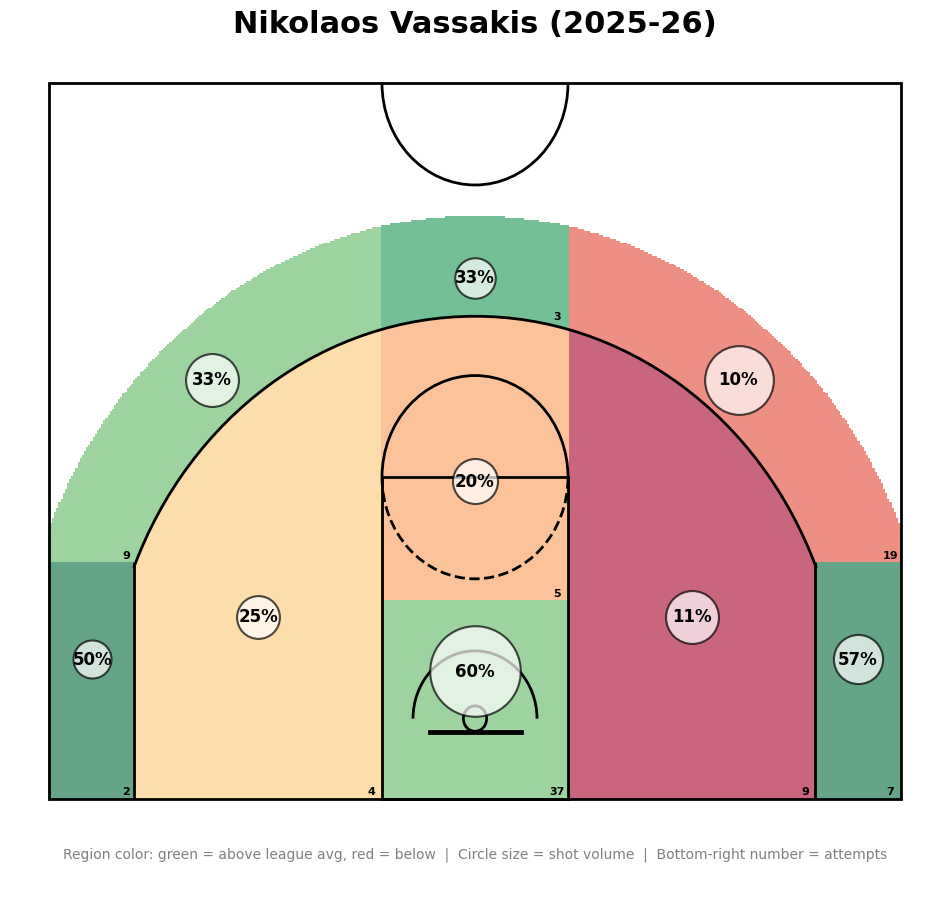

In [29]:
# Where to print the attempts for each region
REGION_ATTEMPT_OFFSETS = {
    "Box":            (53,  -43),
    "Left Side":      (-67, -43),
    "Right Side":     (213, -43),
    "Top Mid-Range":  (53,   74),
    "Top 3pt":        (53,  237),
    "Left-45 3pt":    (-225, 96),
    "Right-45 3pt":   (268,  96),
    "Left Corner 3":  (-225, -43),
    "Right Corner 3": (268, -43),
}

# Map region names to numbers
REGION_NUMBERS = {
    "Box": 0, "Left Side": 1, "Right Side": 2, "Top Mid-Range": 3,
    "Left Corner 3": 4, "Right Corner 3": 5,
    "Left-45 3pt": 6, "Right-45 3pt": 7, "Top 3pt": 8,
}
# Fill the value grid with the VS_LEAGUE values to be painted
value_grid = np.full(X.shape, np.nan)    
for _, region in comparison.iterrows():
    region_name = region["REGION"]               
    region_num = REGION_NUMBERS[region_name]     
    vs_league = region["VS_LEAGUE"]              
    # Mask for the cells in this region
    cells_in_this_region = (region_grid == region_num)
    # Fill only those cells with the vs_league value
    value_grid[cells_in_this_region] = vs_league    

# Prevent coloring below the baseline
value_grid[Y < -47.5] = np.nan

# Color the court based on the VS_LEAGUE values
fig, ax = plt.subplots(figsize=(12, 11))
color_scale = TwoSlopeNorm(vcenter=0, vmin=-15, vmax=15)
ax.pcolormesh(X, Y, value_grid, cmap=plt.cm.RdYlGn,
              norm=color_scale, alpha=0.6, zorder=0)
draw_court(ax, outer_lines=True)

# Add the circles on the shot chart
for _, row in comparison.iterrows():
    cx, cy = REGION_CENTERS[row["REGION"]]
    circle_size = 550 + 3700 * (row["ATTEMPTS"] / max_attempts)

    # White circle at the region center
    ax.scatter(cx, cy, s=circle_size, color="white", edgecolors="black",
               linewidths=1.5, zorder=5, alpha=0.7)

    # FG% in the middle of the circle
    ax.text(cx, cy, f"{row['FG_PCT']:.0f}%",
            ha="center", va="center", fontsize=12, fontweight="bold",
            color="black", zorder=6)

    # Number of attempts on that region
    ox, oy = REGION_ATTEMPT_OFFSETS[row["REGION"]]
    ax.text(ox, oy, f"{int(row['ATTEMPTS'])}",
            ha="center", va="center", fontsize=8, fontweight="bold",
            color="black", zorder=7)

# Final styling
ax.set_xlim(-300, 300)
ax.set_ylim(-100, 400)
ax.set_title(f"{PLAYER_NAME} ({SEASON})", fontsize=22, fontweight="bold")
# Hide axes ticks and border box
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# Explanatory caption
ax.text(0, -80,
        "Region color: green = above league avg, red = below  |  "
        "Circle size = shot volume  |  Bottom-right number = attempts",
        ha="center", va="center", fontsize=10, color="gray")

plt.show()

In [30]:
comparison

,REGION,ATTEMPTS,MADE,FG_PCT,LEAGUE_PCT,VS_LEAGUE
0,Box,37,22,59.5,50.1,9.4
1,Right-45 3pt,19,2,10.5,21.5,-11.0
2,Left-45 3pt,9,3,33.3,23.9,9.4
3,Right Side,9,1,11.1,27.6,-16.5
4,Right Corner 3,7,4,57.1,27.7,29.4
5,Top Mid-Range,5,1,20.0,26.9,-6.9
6,Left Side,4,1,25.0,29.5,-4.5
7,Top 3pt,3,1,33.3,21.2,12.1
8,Left Corner 3,2,1,50.0,21.6,28.4
